# Shor's Algorithm

In this module, you will:
- Understand how **Shor's algorithm** factors integers with an **exponential speedup** over the best known classical algorithms.
- Build the period-finding circuit step-by-step using the QpiAI Quantum SDK, both **manually** with `Circuit` and via the high-level `ShorsAlgorithm` class.
- Analyze the **mathematical foundation**: modular exponentiation, the Quantum Fourier Transform, continued fractions, and why measuring yields information about the period.
- Run experiments on a **simulator** and verify that the algorithm correctly factors small composite numbers.

## What is Shor's Algorithm?

Given a composite integer $N$, the goal is to find non-trivial factors $p$ and $q$ such that $N = p \times q$.

Shor's algorithm reduces factoring to a **period-finding** problem:

1. **Choose** a random integer $a$ with $1 < a < N$ and $\gcd(a, N) = 1$.
2. **Find the period** $r$ of the function $f(x) = a^x \bmod N$, i.e., the smallest positive integer $r$ such that $a^r \equiv 1 \pmod{N}$.
3. **Extract factors** from $r$: if $r$ is even and $a^{r/2} \not\equiv -1 \pmod{N}$, then $\gcd(a^{r/2} \pm 1, N)$ gives non-trivial factors of $N$. If $r$ is odd, or if $a^{r/2} \equiv -1 \pmod{N}$, the period-finding fails for this $a$, and we must choose a new random $a$ and repeat the process.

**The Challenge:** Finding the period $r$ is the computationally hard part.

- **Classically**, the best known general-purpose factoring algorithm (Number Field Sieve) runs in **sub-exponential** time: $O\left(e^{c \cdot (\ln N)^{1/3} (\ln \ln N)^{2/3}}\right)$.
- **Quantumly**, Shor's algorithm finds $r$ using the **Quantum Fourier Transform** in **$O((\log N)^3)$** time: an exponential speedup.

**Key Insight:** Shor's algorithm combines three powerful ideas:
1. **Modular exponentiation** in superposition: evaluating $a^x \bmod N$ for all $x$ simultaneously.
2. **Quantum Fourier Transform**: converting the periodic structure of the quantum state into a measurable signal.
3. **Continued fractions**: classical post-processing to extract the exact period from the measurement outcome.

> **Note:** This is an educational implementation suitable for small values of $N$ (up to about 20). Production-grade implementations require efficient modular exponentiation circuits that scale to large $N$.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `ShorsAlgorithm`: high-level algorithm class that builds and runs the period-finding circuit, and extracts factors.
- `Circuit`: low-level circuit construction API (for manual circuit building).
- `QFT`: Quantum Fourier Transform, used as a subroutine in the period-finding circuit.
- **Gates:** `h` (Hadamard), `x` (Pauli-X), `cx` (CNOT), `cp` (controlled-phase).
- **Circuit utilities:** `show()`, `list_gates()`.
- **Execution:** `Circuit.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.counts`.

We will first build the circuit **manually** to understand each stage, then use the high-level `ShorsAlgorithm` class for convenience.

## 3. Code: Building Shor's Period-Finding Circuit

Shor's circuit operates on **two registers**:
- A **precision register** of $t$ qubits (qubits $0$ to $t-1$), where $t = 2\lceil\log_2 N\rceil$.
- A **target register** of $n = \lceil\log_2 N\rceil$ qubits (qubits $t$ to $t+n-1$).

The circuit has **four stages**:

1. **Superposition:** Apply $H^{\otimes t}$ to the precision register to create a uniform superposition over all $t$-bit strings.
2. **Initialize target:** Set the target register to $|1\rangle$ (by applying $X$ to the first target qubit).
3. **Controlled modular exponentiation:** For each precision qubit $j$, apply the controlled operation $U^{2^{t-1-j}}$ where $U|y\rangle = |a \cdot y \bmod N\rangle$. This encodes the periodic structure of $a^x \bmod N$ into the quantum state.
4. **Inverse QFT:** Apply the inverse Quantum Fourier Transform to the precision register. This converts the periodic signal into a measurable phase.
5. **Measurement:** Measure the $t$ precision qubits. The result encodes $s/r$ (a multiple of $1/r$) from which the period $r$ can be extracted via continued fractions.

### 3a. Manual Construction with `Circuit`

Let's build a simplified period-finding circuit for $N = 15$ and $a = 7$.

Factoring N = 15 with a = 7
Target qubits: 4, Precision qubits: 8, Total: 12

=== Manual Shor's Circuit for N=15, a=7 ===


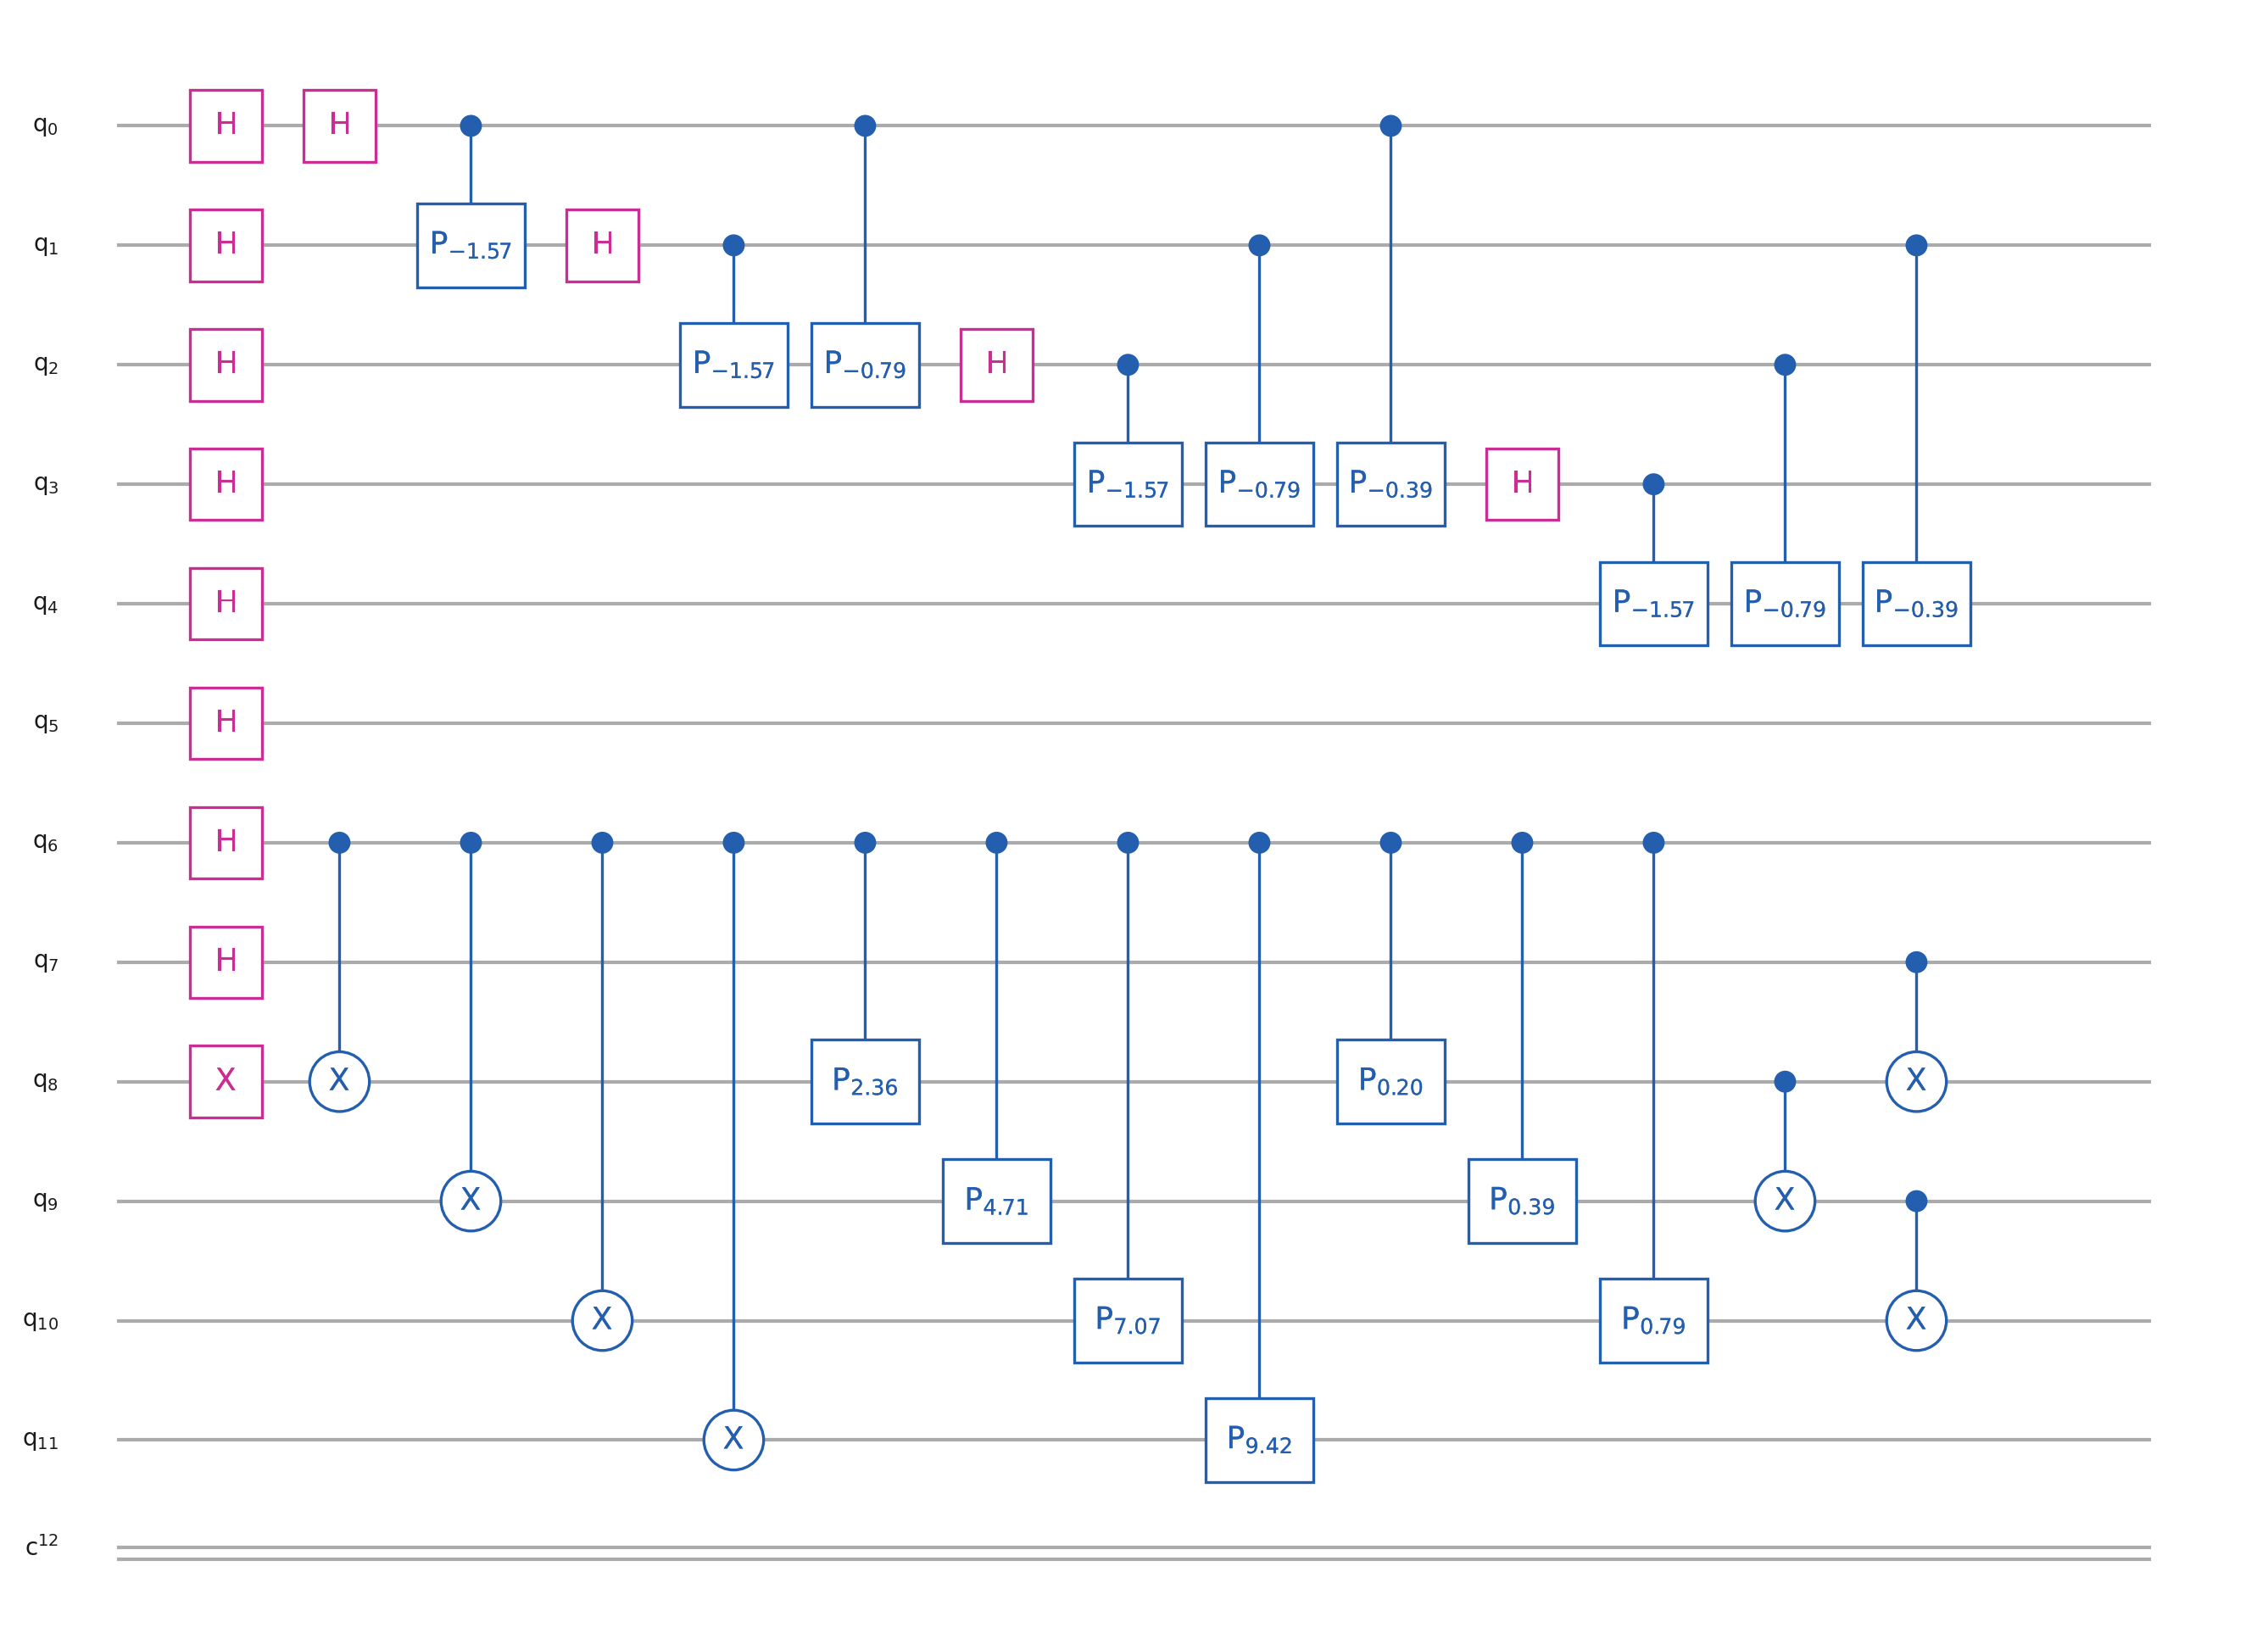

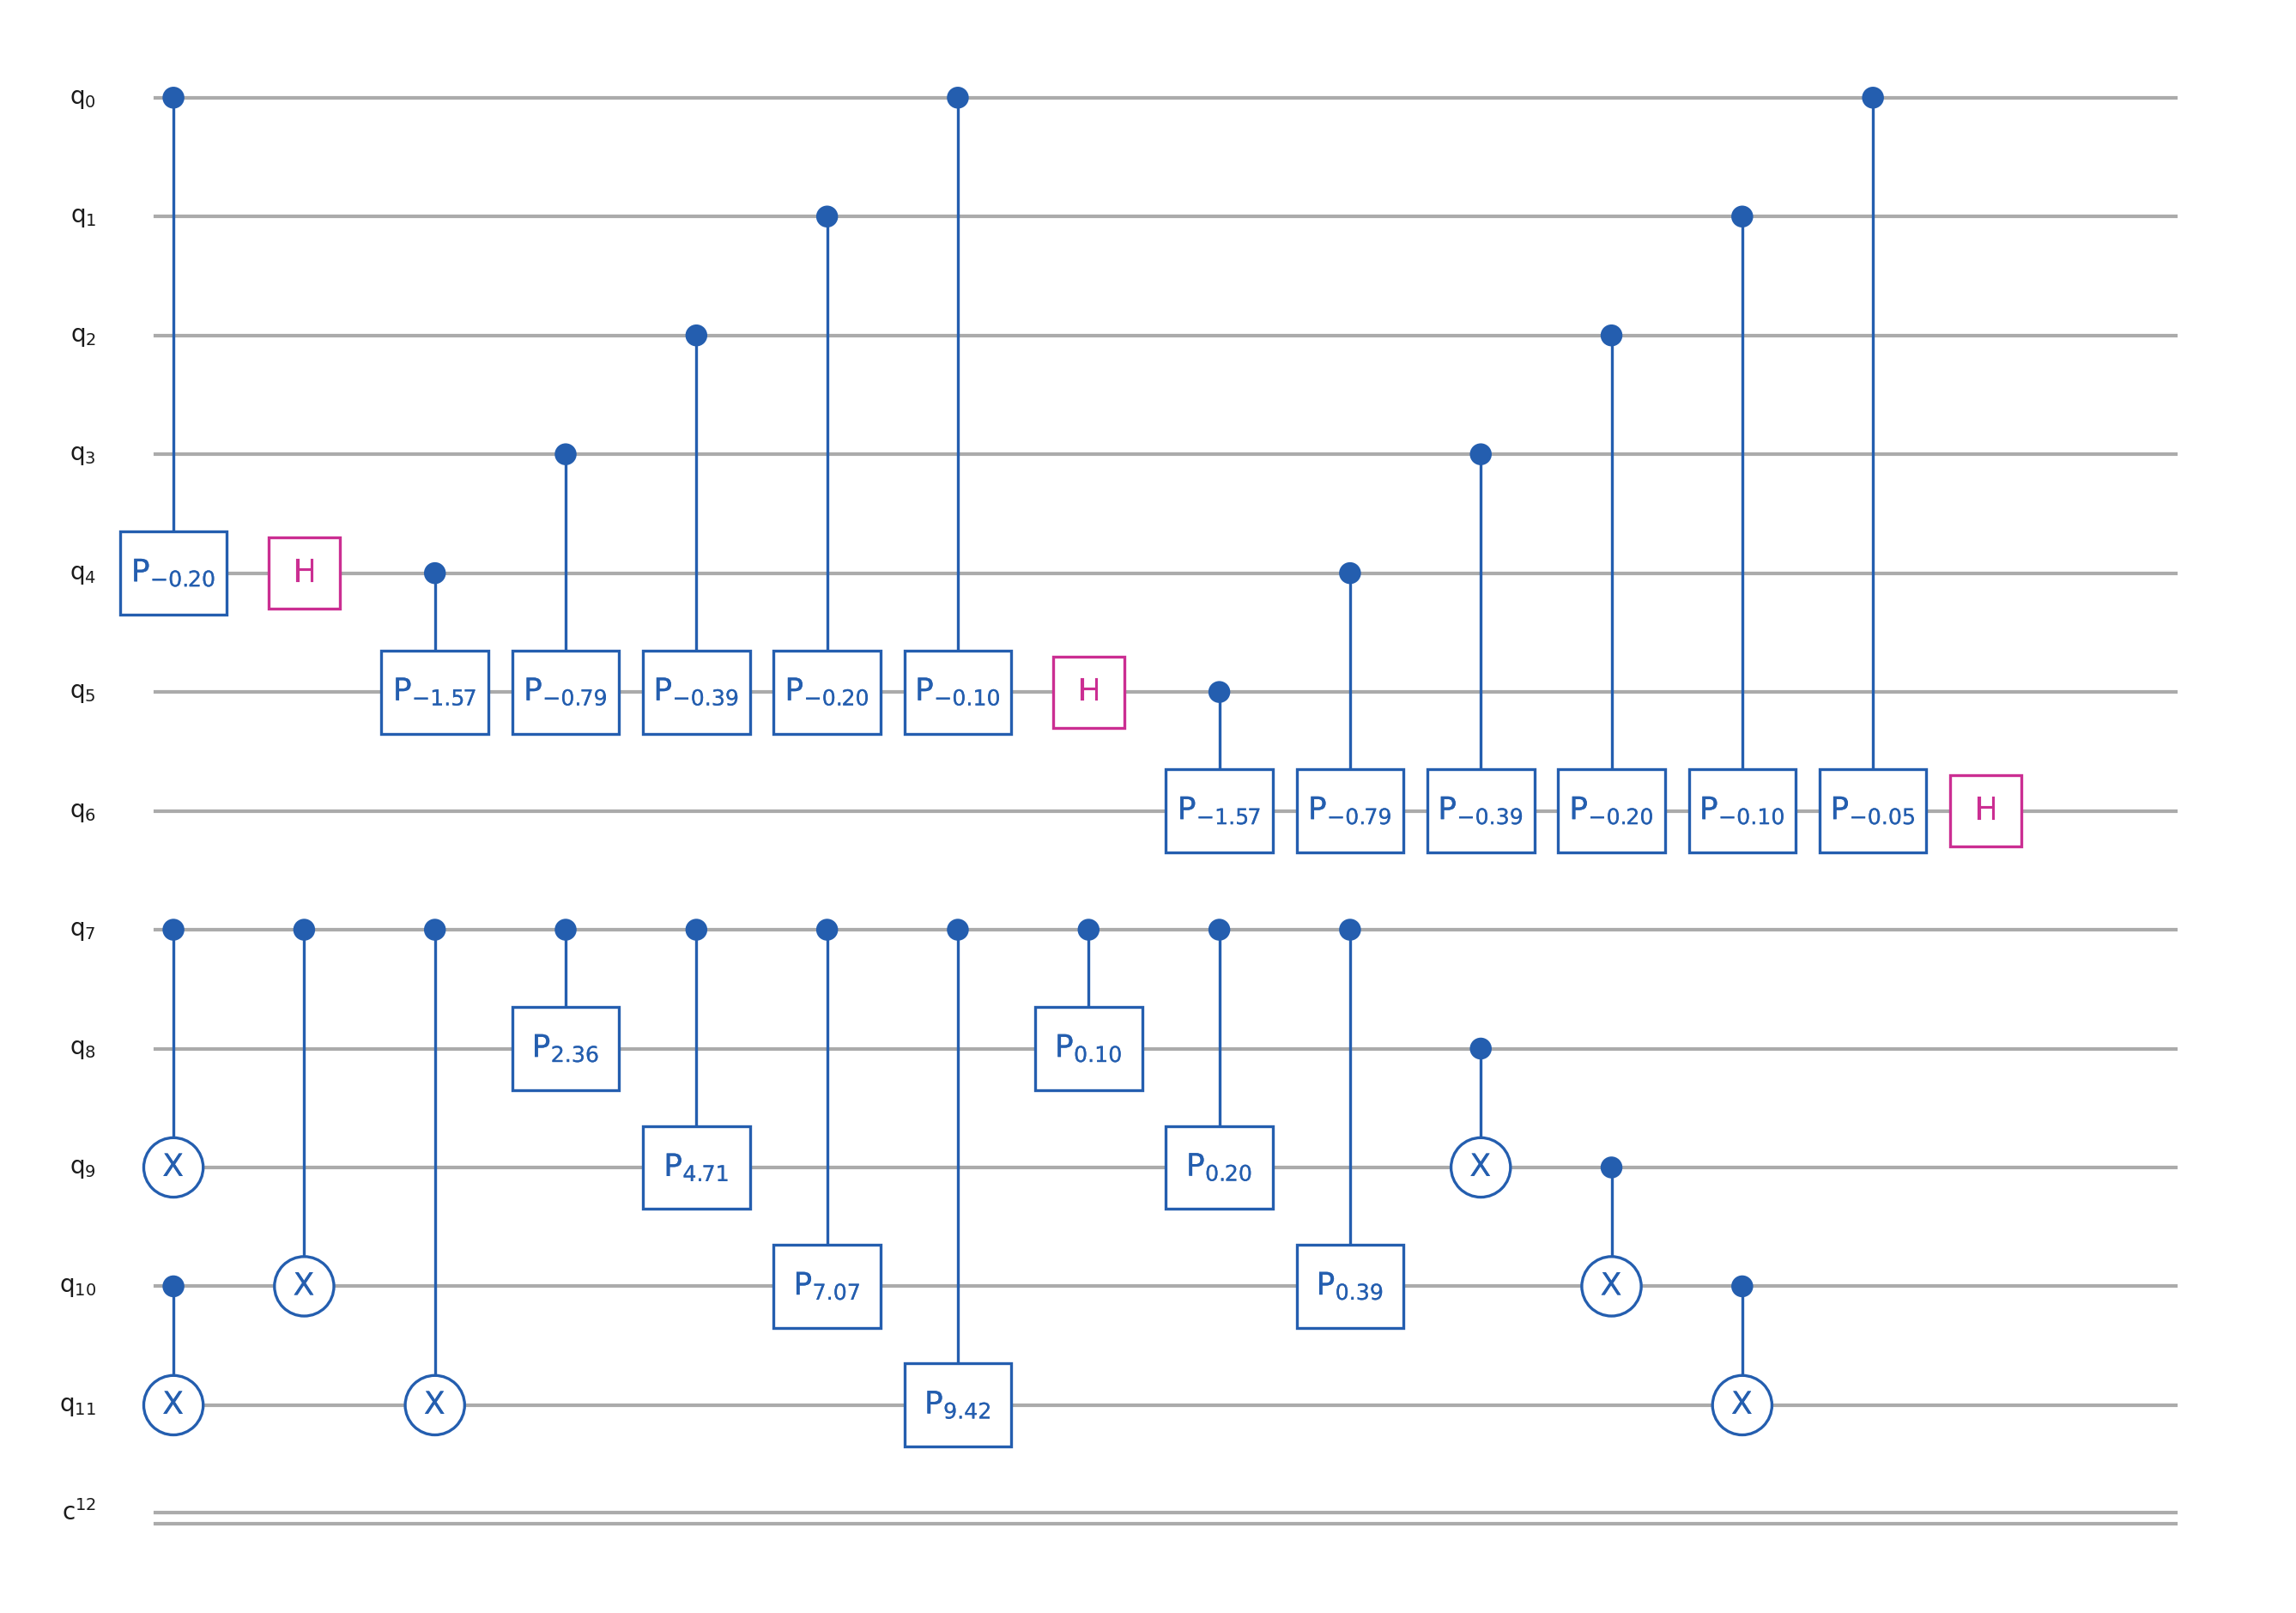

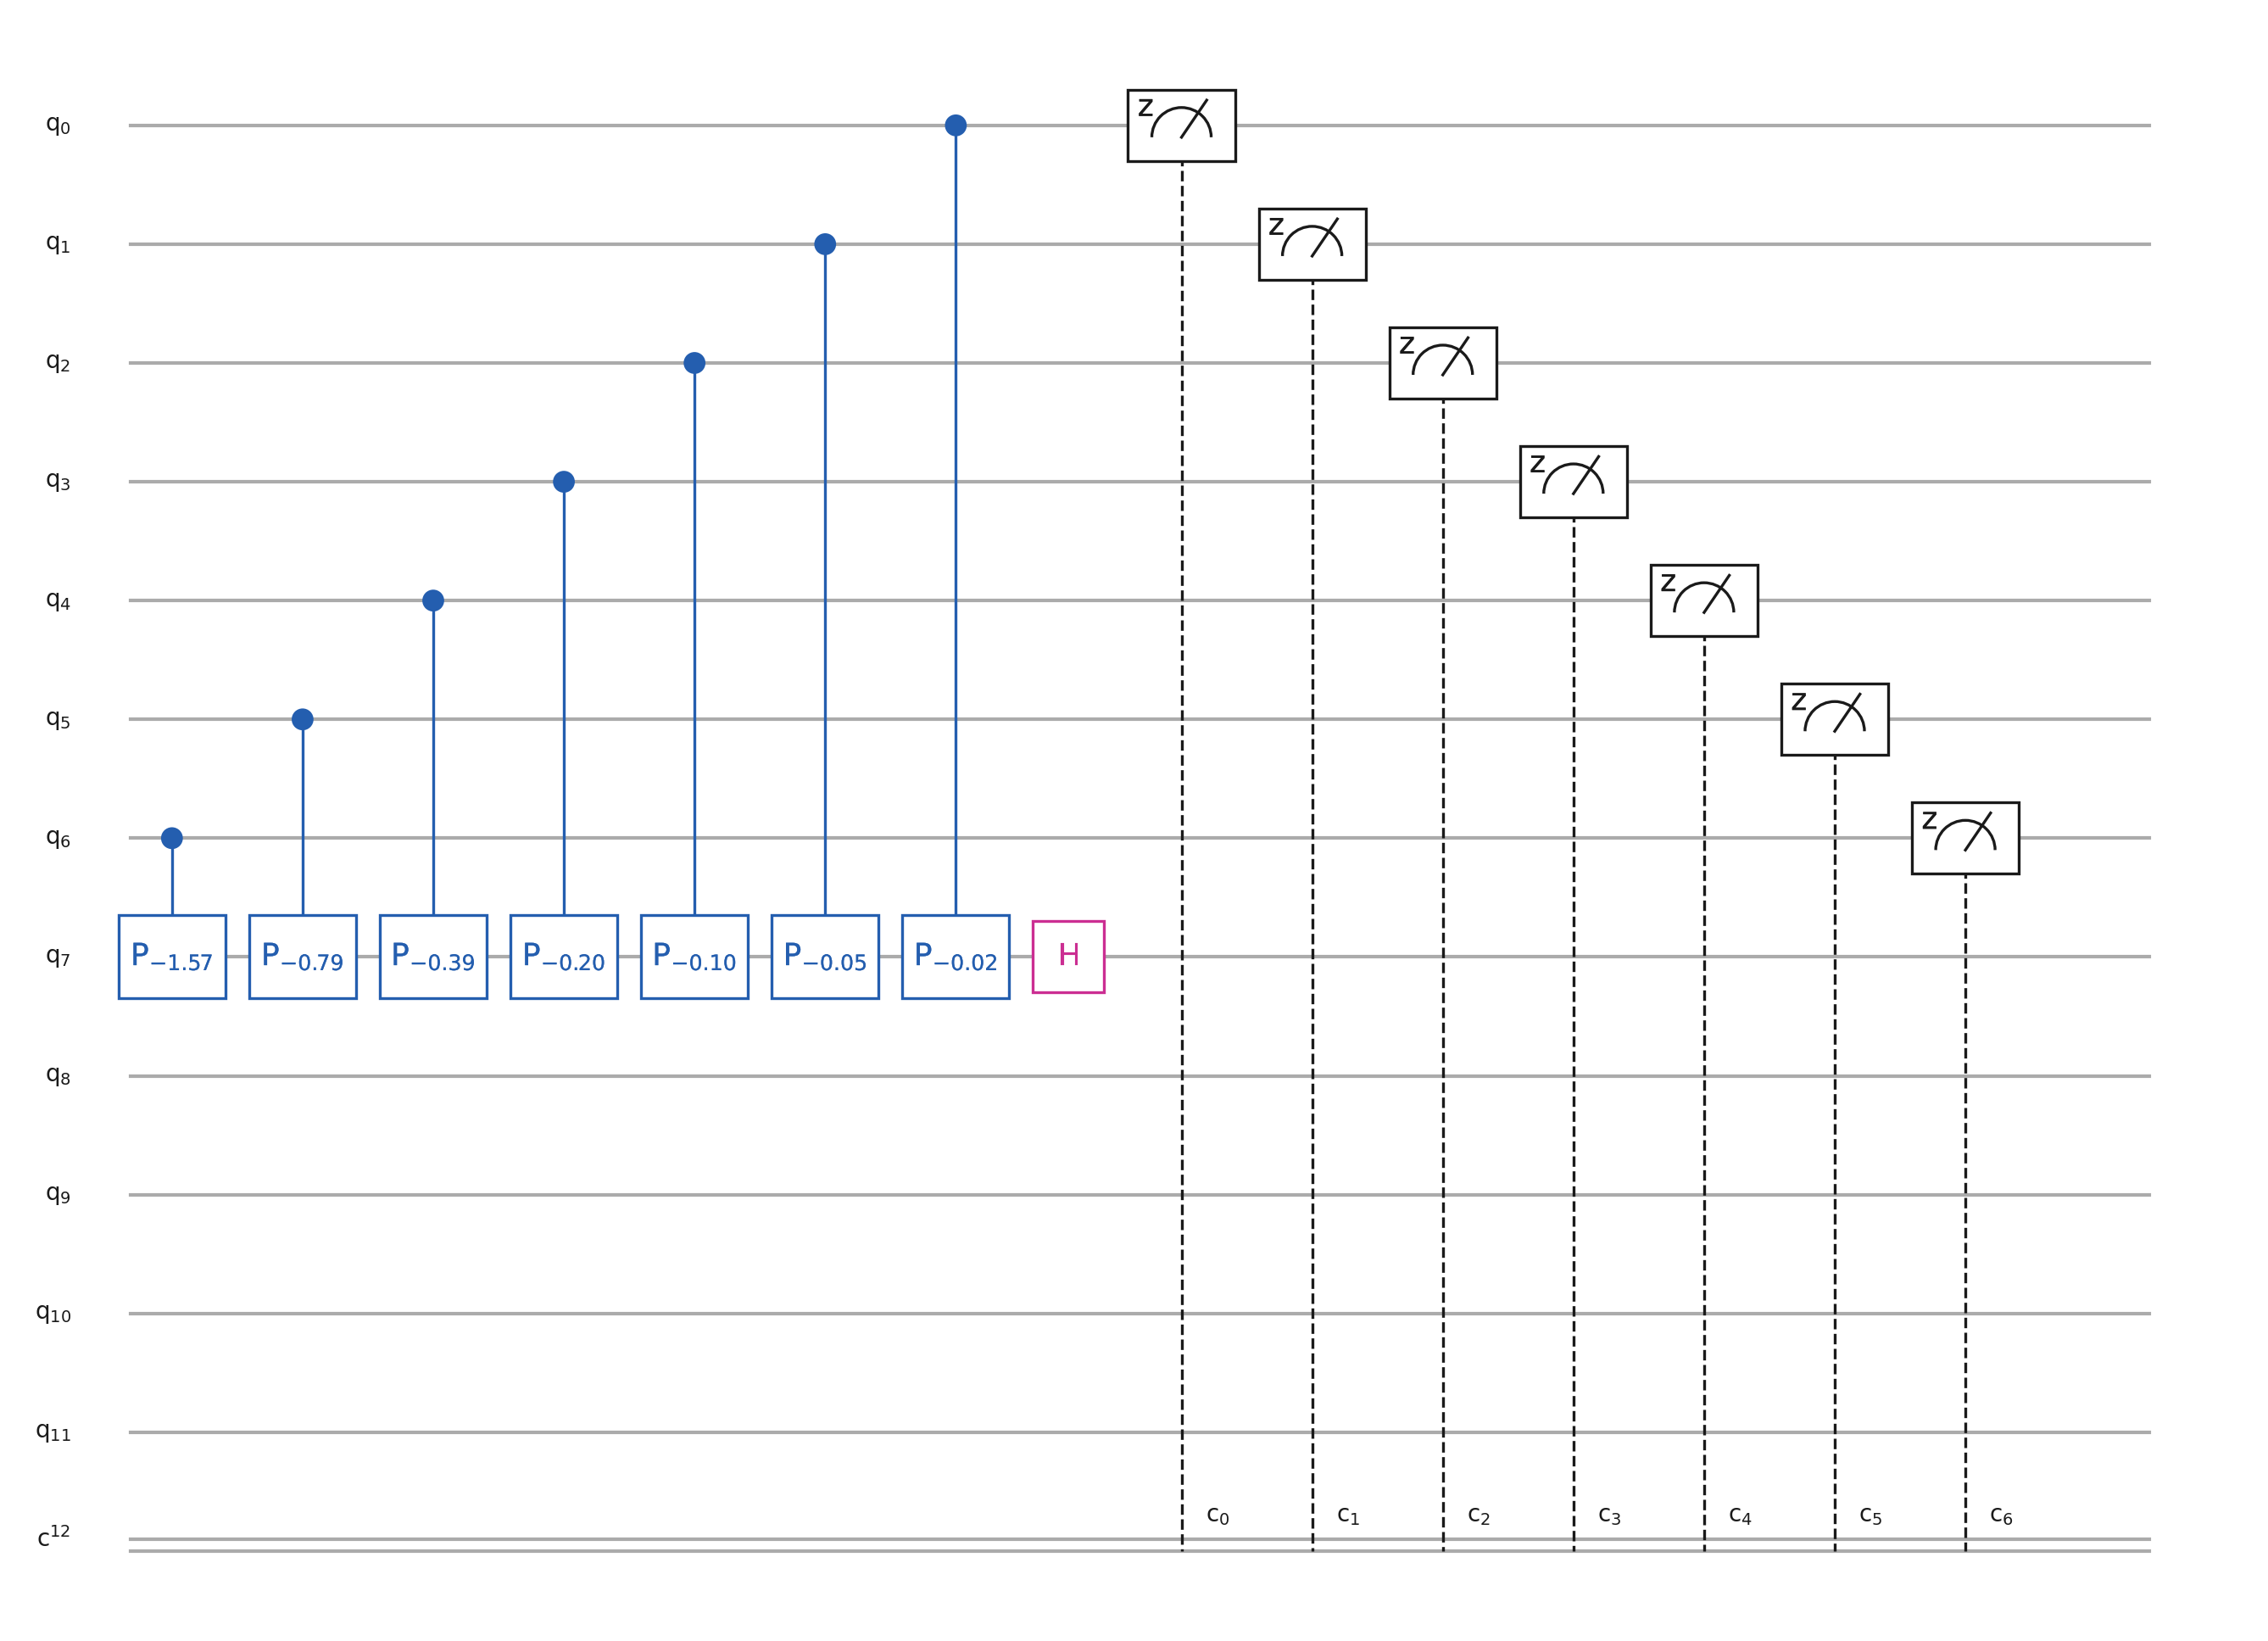

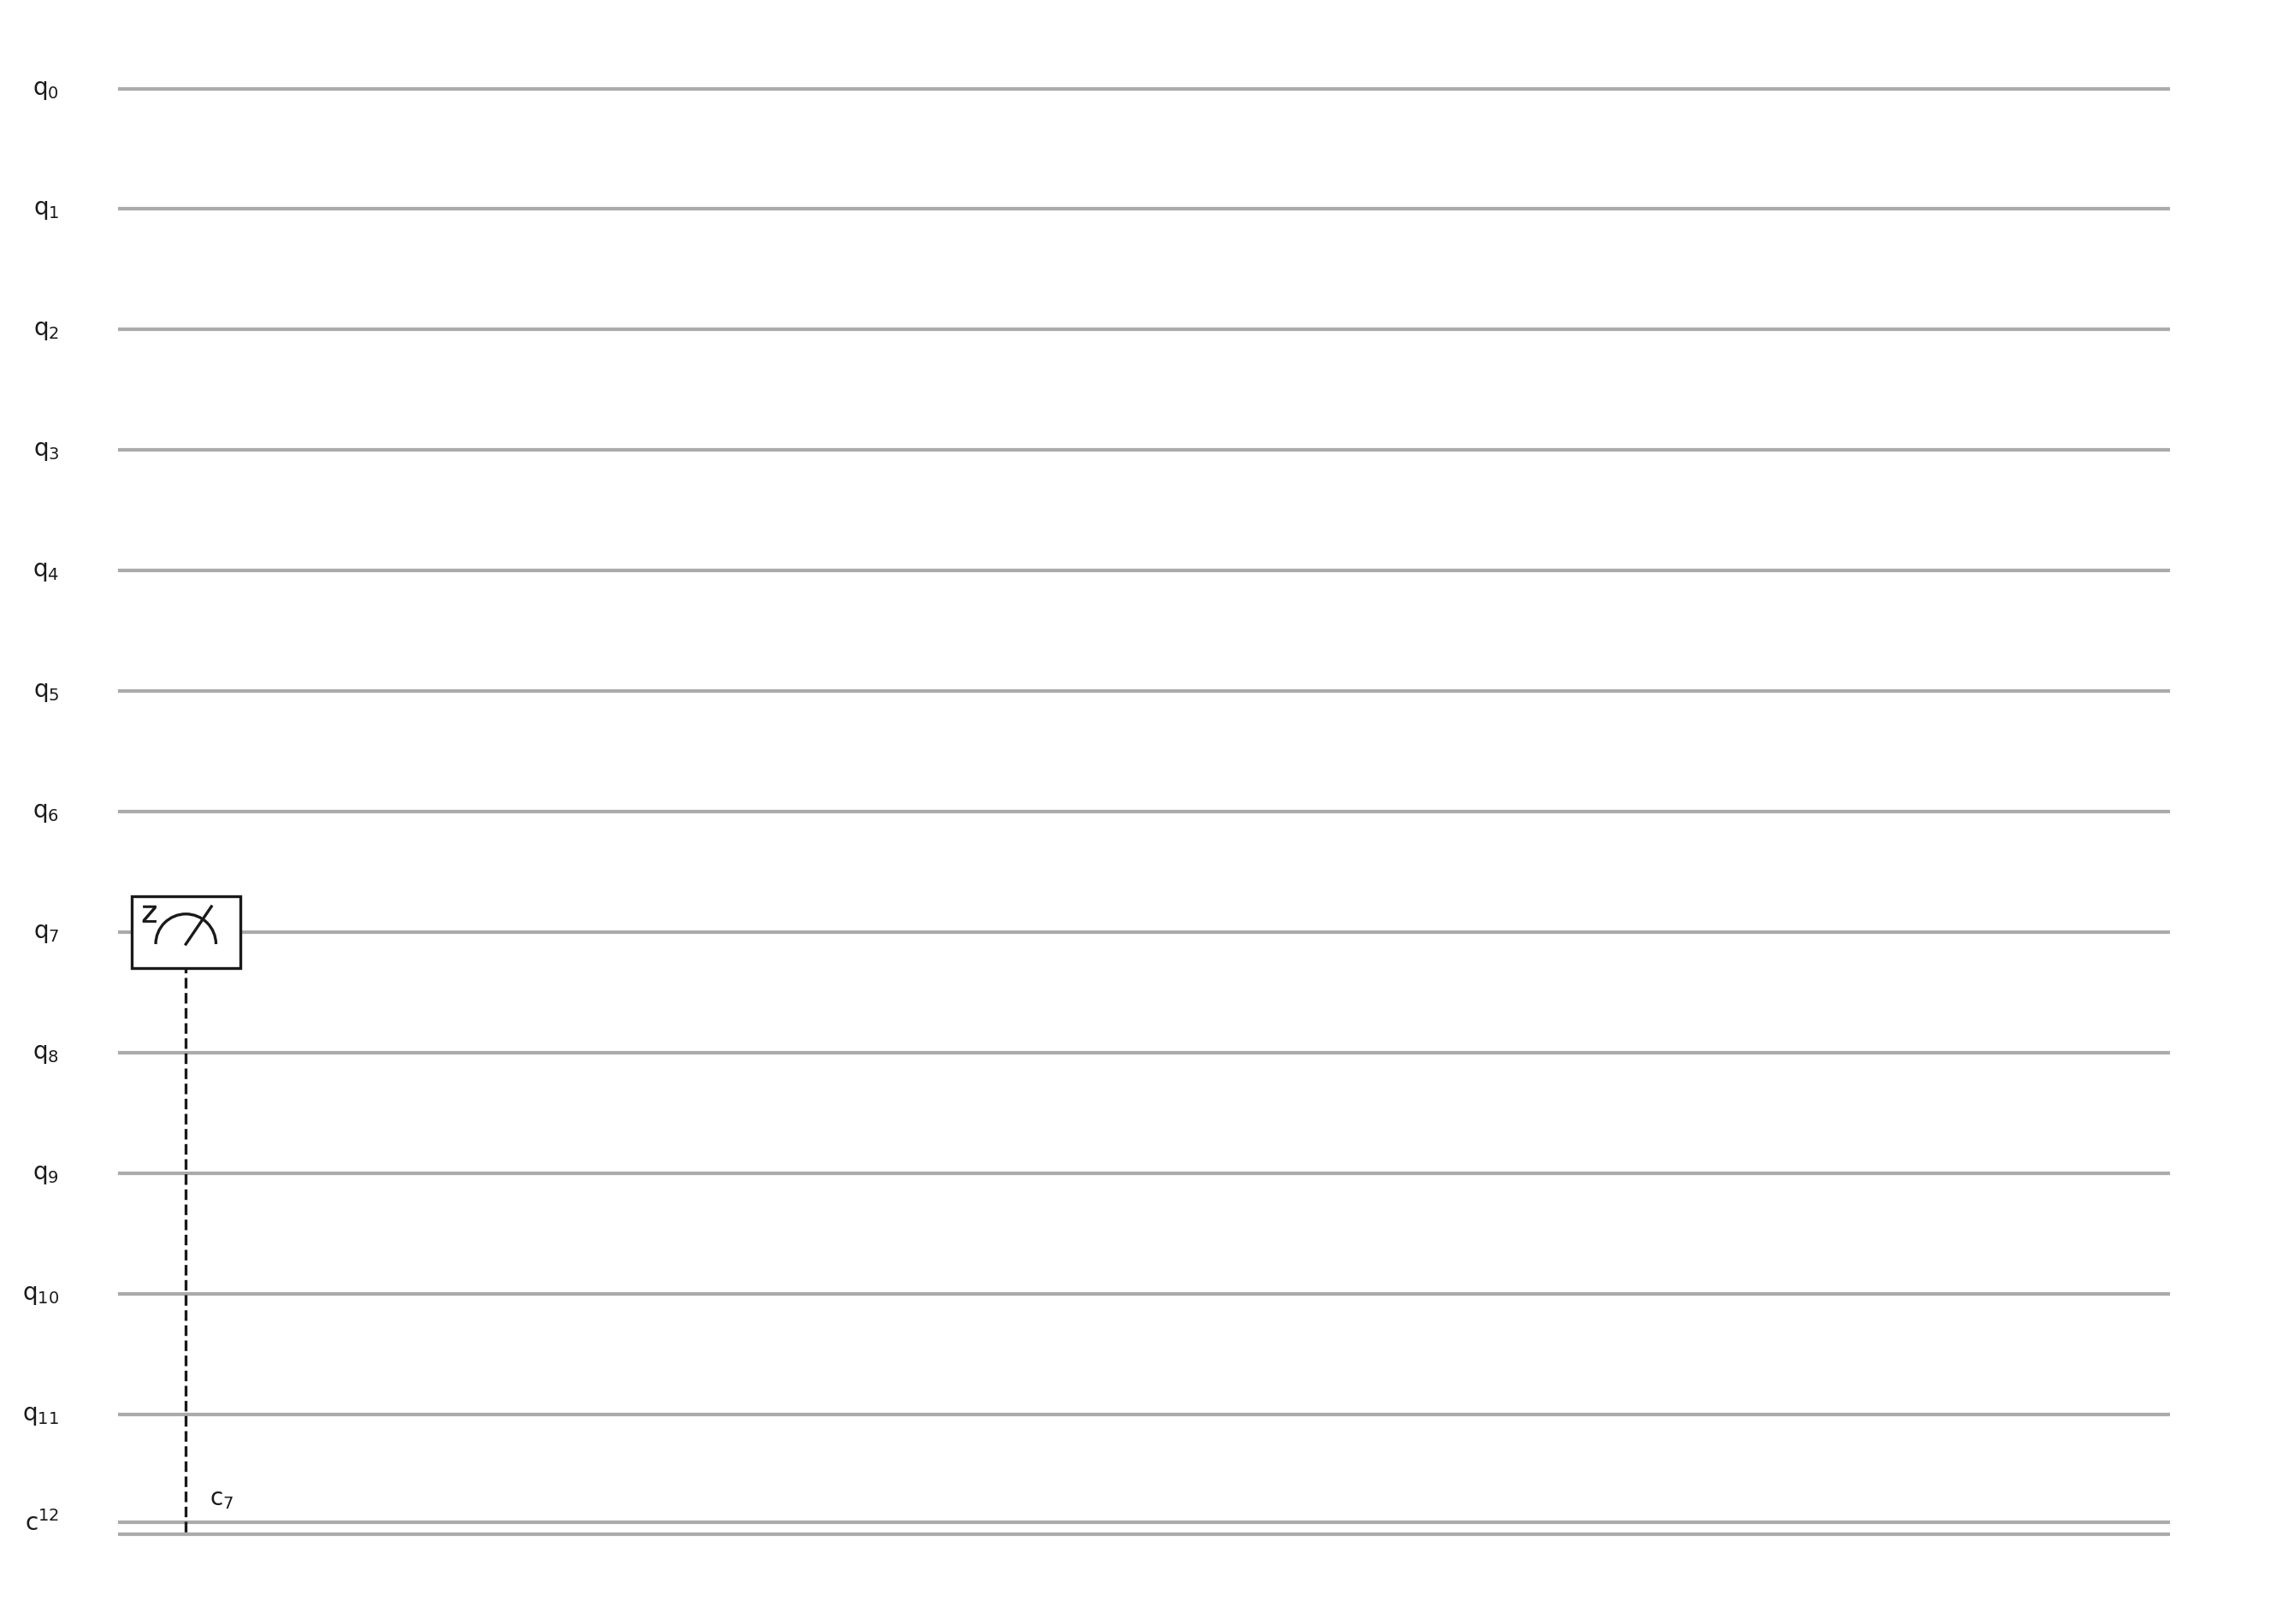

Gate stats: {'total_operations': 81, 'total_gates': 73, 'single_qubit_gates': 17, 'two_qubit_gates': 56, 'multi_qubit_gates': 0, 'clifford_gates': 31, 'non_clifford_gates': 42, 'parametric_gates': 42, 'measurements': 8, 'barriers': 0, 'gate_counts': {'H': 16, 'X': 1, 'CX': 14, 'CP': 42, 'MEASURE': 8}}


In [2]:
import math
from qpiai_quantum import Circuit
from qpiai_quantum.algorithms.qft import QFT

N = 15
a = 7

# Calculate qubit counts
n_target = math.ceil(math.log2(N))   # target register size
n_precision = 2 * n_target            # precision register size (2*ceil(log2(N)))
total_qubits = n_precision + n_target

print(f"Factoring N = {N} with a = {a}")
print(f"Target qubits: {n_target}, Precision qubits: {n_precision}, Total: {total_qubits}")

# Create circuit: total_qubits quantum, n_precision classical bits
circuit = Circuit(total_qubits, n_precision, name="shor_manual_circuit")

# ── Stage 1: Superposition on precision register ──
# |0⟩^t → (1/√2^t) Σ_x |x⟩
for i in range(n_precision):
    circuit.h(i)

# ── Stage 2: Initialize target register to |1⟩ ──
circuit.x(n_precision)

# ── Stage 3: Controlled modular exponentiation (educational) ──
# For each control qubit j, apply controlled U^(2^(t-1-j))
# where U|y⟩ = |a*y mod N⟩
# This is a simplified/educational encoding of the modular structure
for j in range(n_precision):
    power = pow(a, 2**(n_precision - 1 - j), N)  # a^(2^(t-1-j)) mod N, computed classically
    offset = n_precision
    
    # Compute multiplicative order of power mod N
    order = 1
    current = power % N
    while current != 1 and order < N:
        current = (current * power) % N
        order += 1
    if current != 1:
        order = 1
    
    # Only apply gates when the controlled operation is non-trivial (order > 1)
    # When power = 1 mod N, the operation is identity, so no gates are needed
    if order > 1:
        # Entangle control with target qubits
        for i in range(n_target):
            circuit.cx(j, offset + i)
        
        # Encode periodic structure via phase gates
        phase_per_order = 2 * math.pi / order
        for i in range(n_target):
            phase = phase_per_order * ((power - 1) * (i + 1)) / n_target
            if abs(phase) > 1e-10:
                circuit.cp(j, offset + i, phase)
        
        for i in range(n_target - 1):
            angle = phase_per_order * (2 ** i) / (2 ** n_target)
            if abs(angle) > 1e-10:
                circuit.cp(j, offset + i, angle)
        
        for i in range(n_target - 1):
            circuit.cx(offset + i, offset + i + 1)

# ── Stage 4: Inverse QFT on precision register ──
QFT.apply_inverse_qft_to_circuit(circuit, 0, n_precision)

# ── Stage 5: Measure precision qubits ──
for i in range(n_precision):
    circuit.measure(i, i)

print(f"\n=== Manual Shor's Circuit for N={N}, a={a} ===")
circuit.show()
print("Gate stats:", circuit.list_gates())

### 3b. High-Level Construction with `ShorsAlgorithm`

The SDK provides a convenient `ShorsAlgorithm` class that wraps all stages above, plus the classical pre- and post-processing (choosing $a$, continued fractions, GCD).

Description: Shor's Factoring Algorithm for N=15
Number of qubits: 8

=== Shor's Circuit (high-level) for N=15, a=7 ===


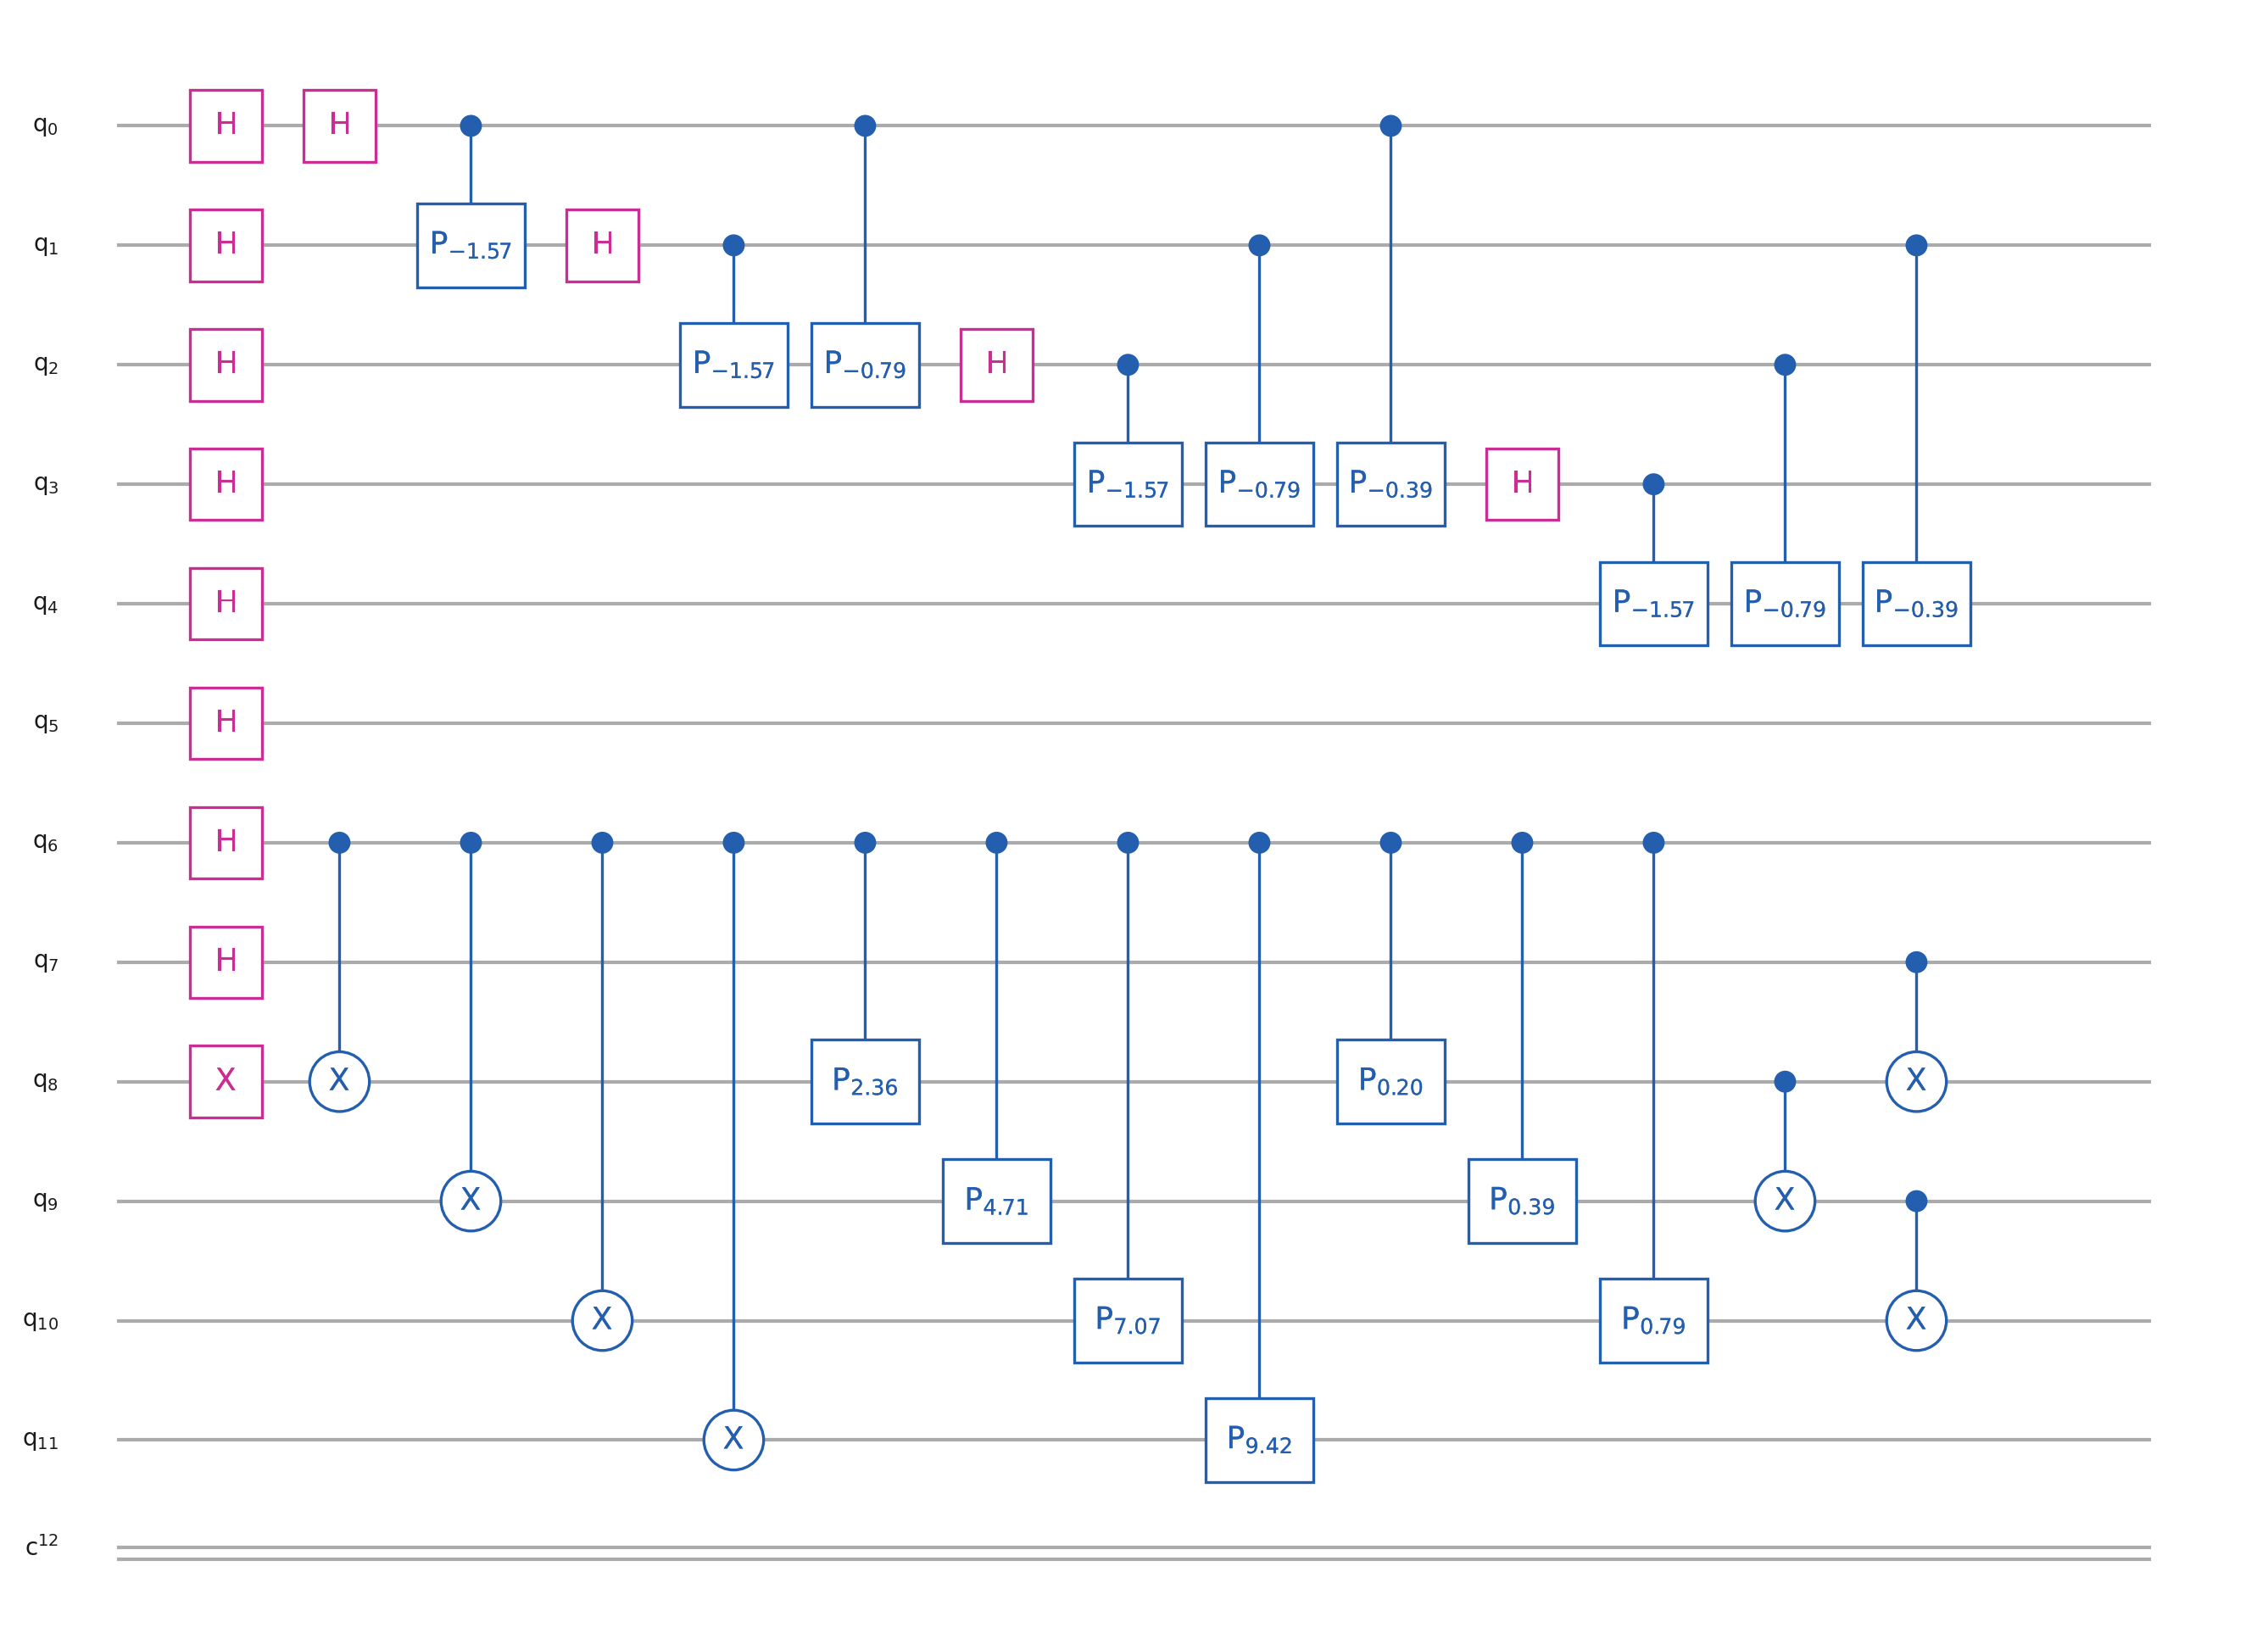

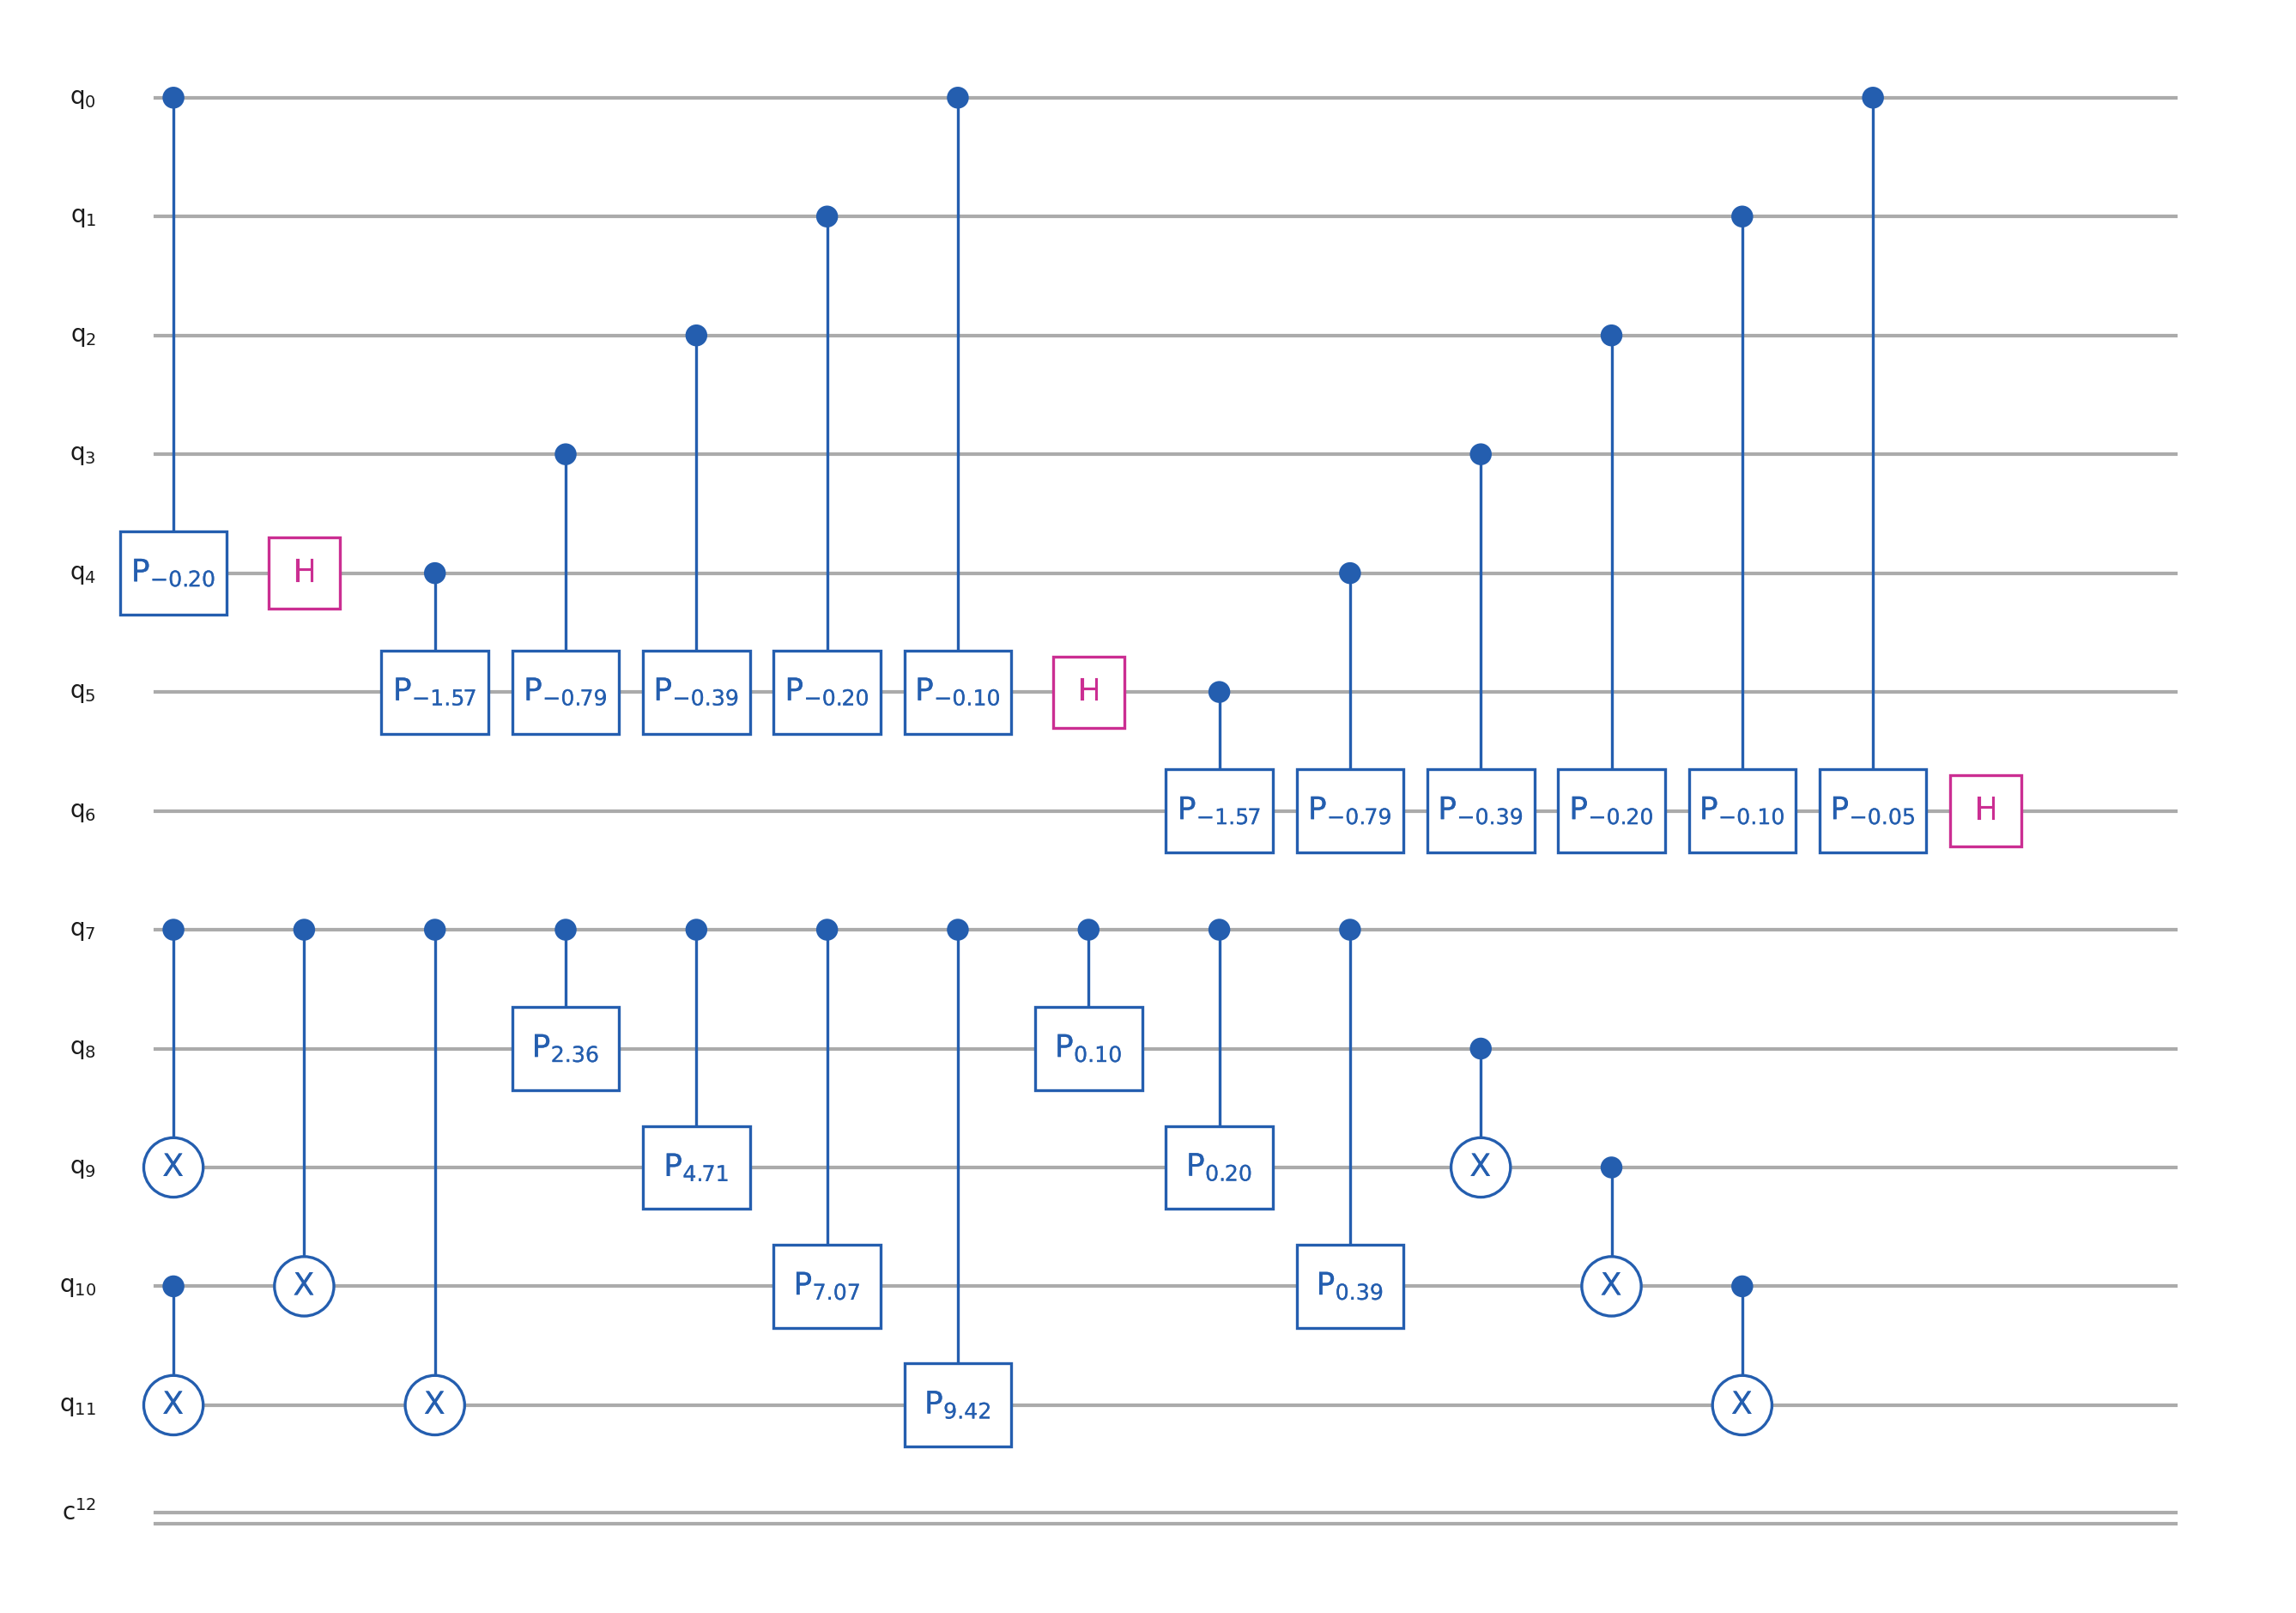

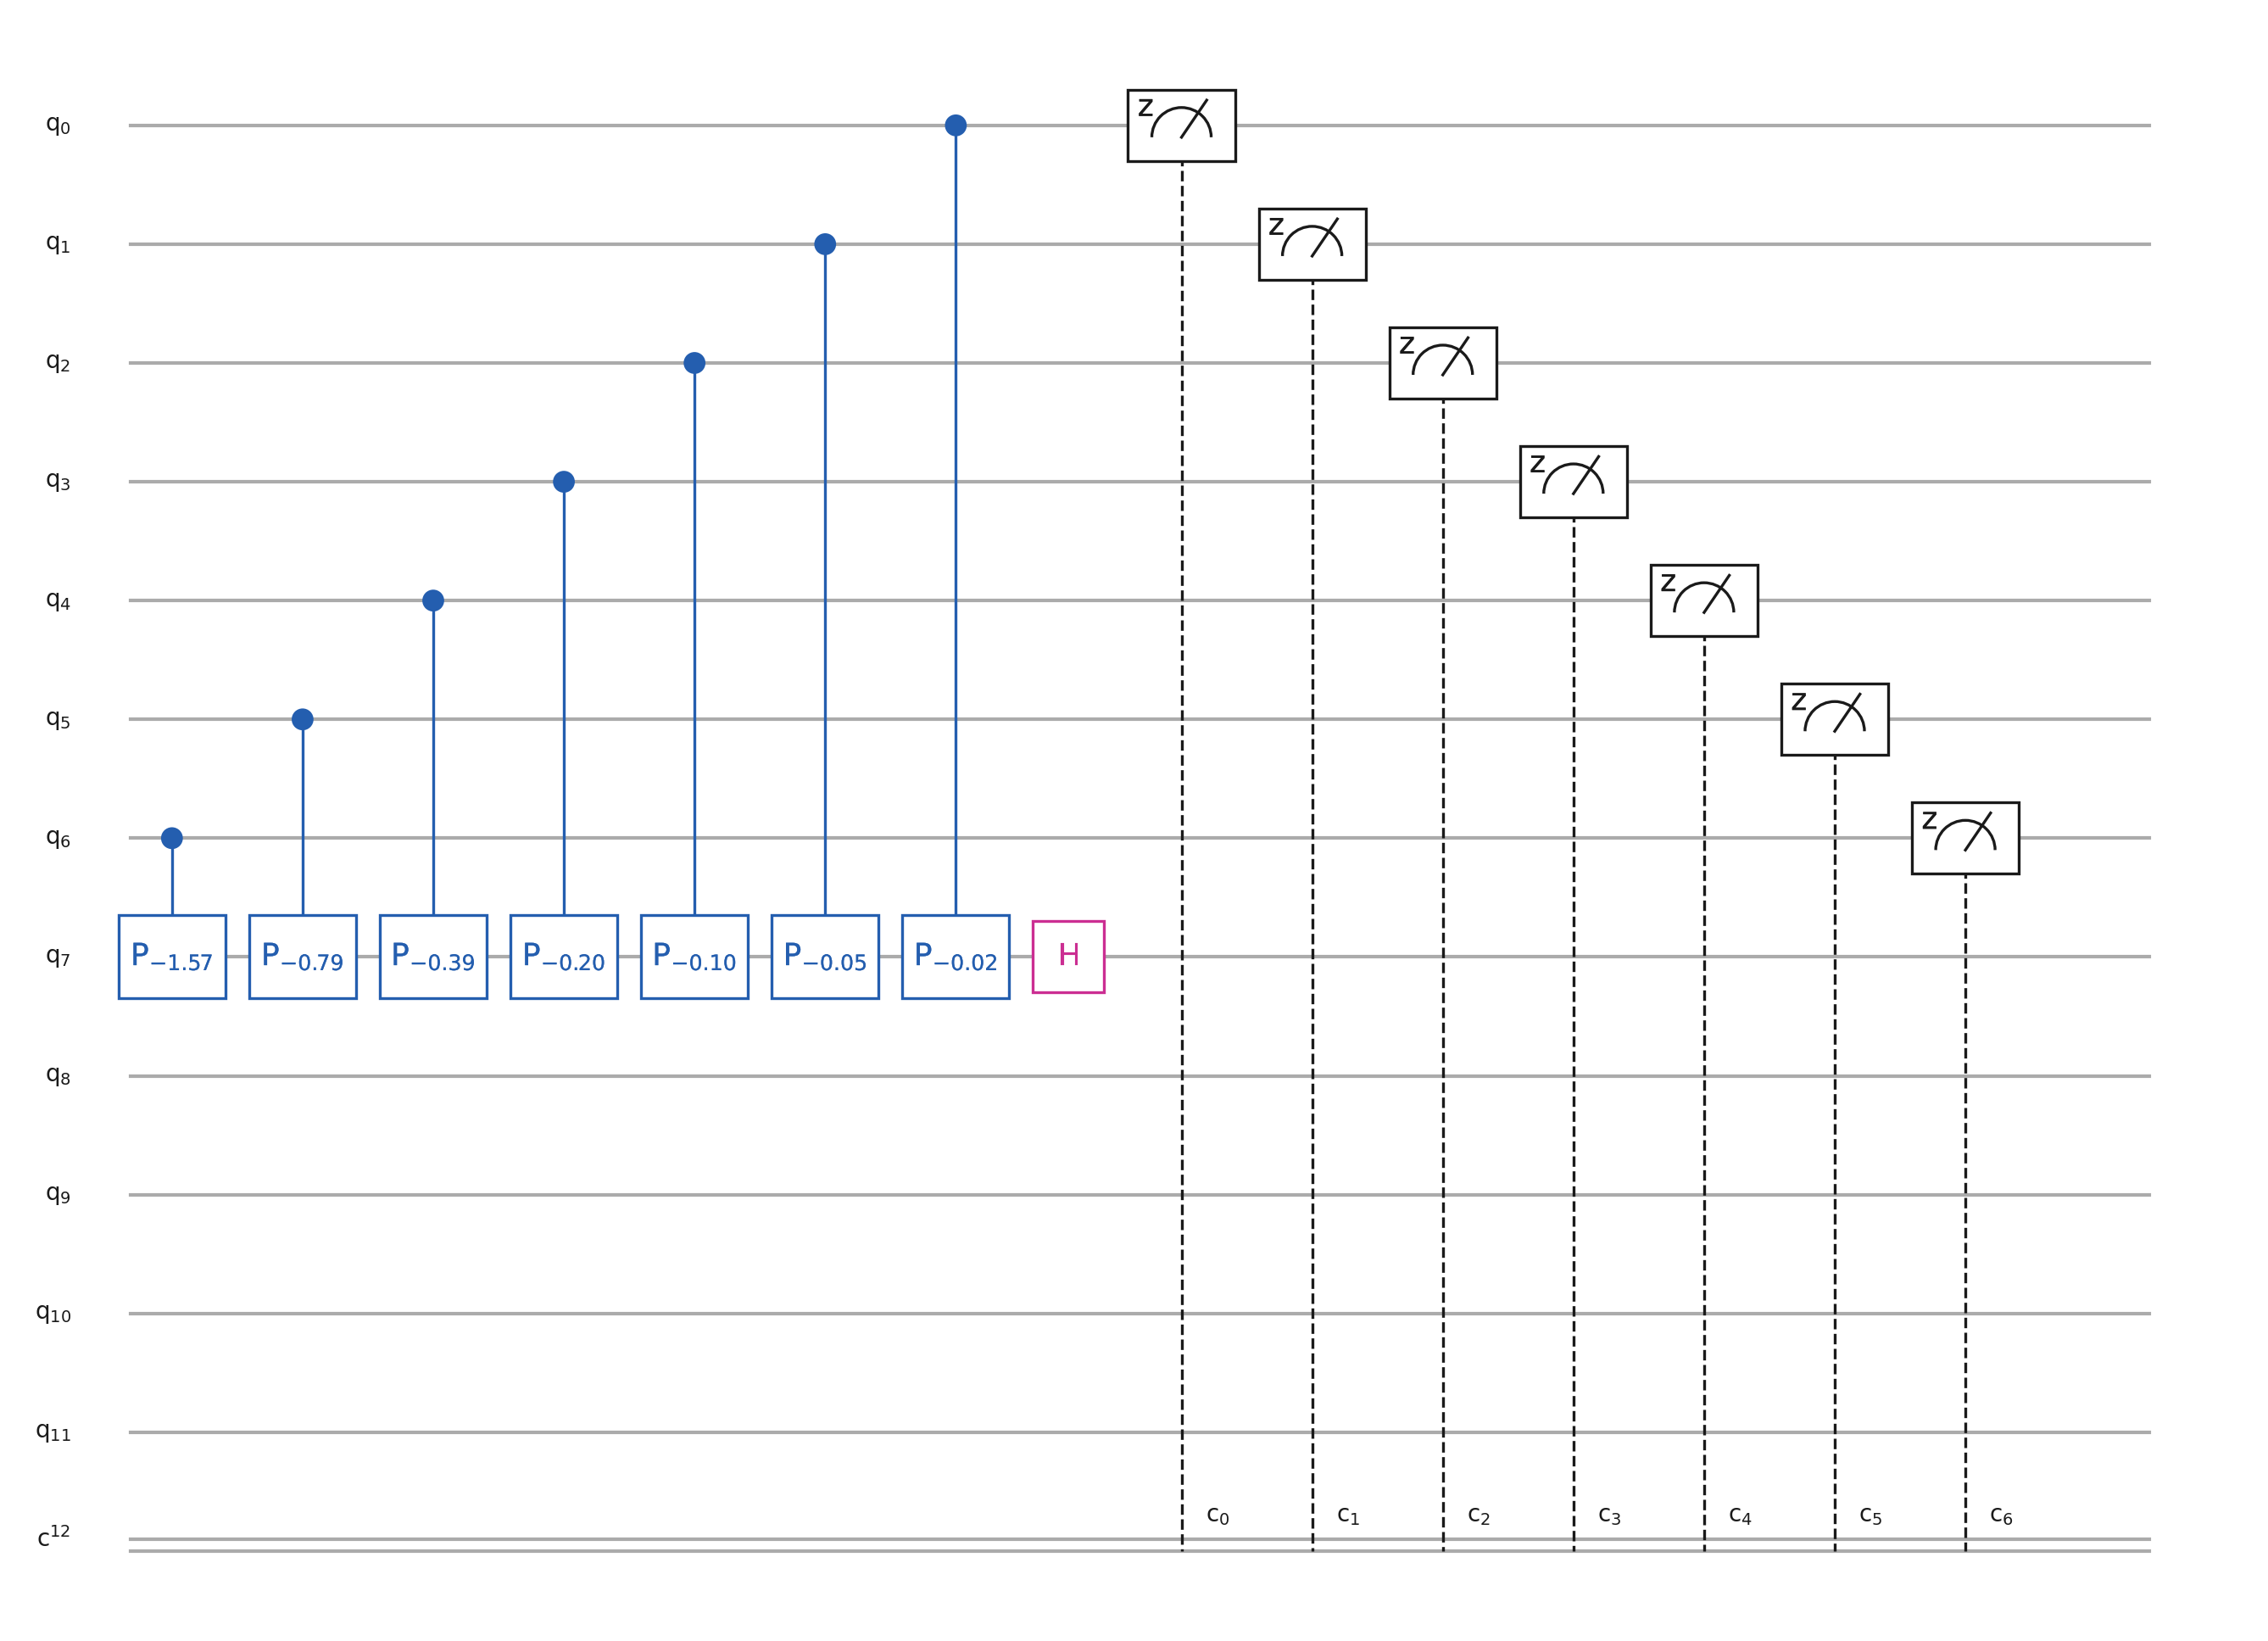

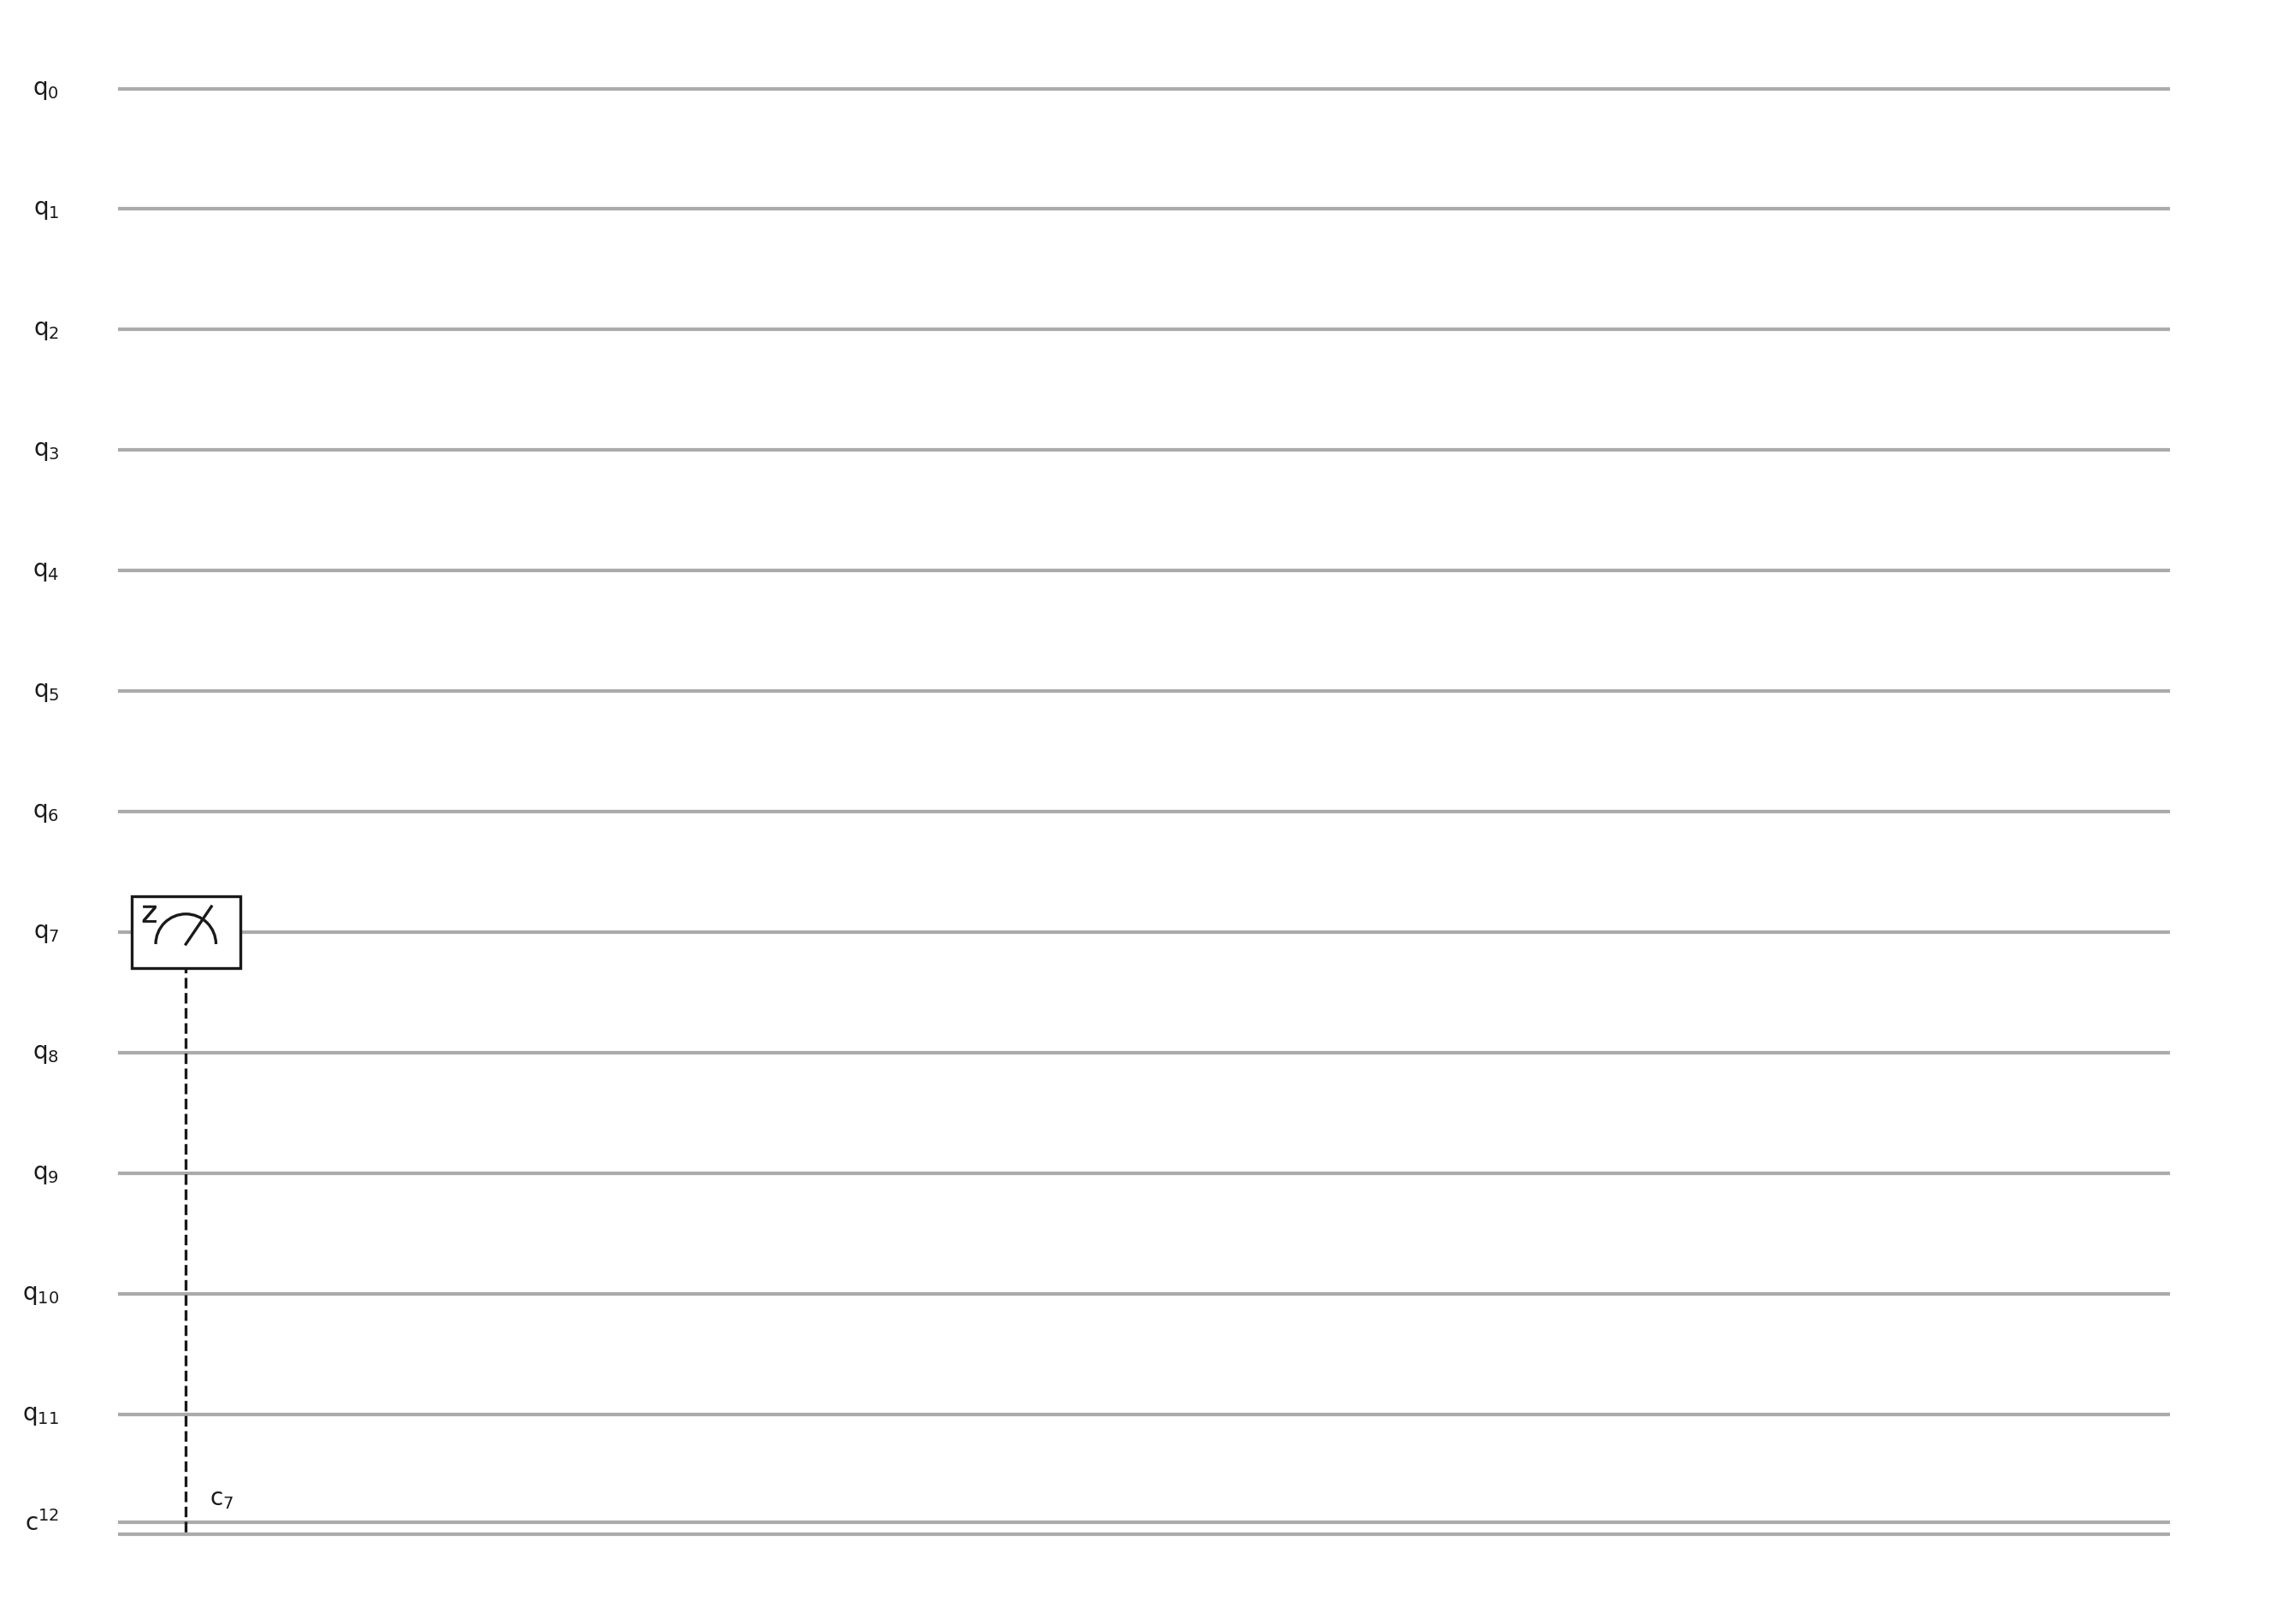

Gate stats: {'total_operations': 81, 'total_gates': 73, 'single_qubit_gates': 17, 'two_qubit_gates': 56, 'multi_qubit_gates': 0, 'clifford_gates': 31, 'non_clifford_gates': 42, 'parametric_gates': 42, 'measurements': 8, 'barriers': 0, 'gate_counts': {'H': 16, 'X': 1, 'CX': 14, 'CP': 42, 'MEASURE': 8}}


In [3]:
from qpiai_quantum.algorithms.shor import ShorsAlgorithm

# Create Shor's instance for N=15
shor = ShorsAlgorithm(N=15)
print("Description:", shor.description)
print(f"Number of qubits: {shor.num_qubits}")

# Build the period-finding circuit for a=7
precision_qubits = 2 * math.ceil(math.log2(15))
shor_circuit = shor.build_circuit(a=7, precision_qubits=precision_qubits)
print(f"\n=== Shor's Circuit (high-level) for N=15, a=7 ===")
shor_circuit.show()
print("Gate stats:", shor_circuit.list_gates())

## 4. Math: Why Shor's Algorithm Works

### The Period-Finding Problem

Given $a$ coprime to $N$, define the function:
$$f(x) = a^x \bmod N$$

This function is **periodic** with period $r$ (the *multiplicative order* of $a$ modulo $N$):
$$f(x + r) = a^{x+r} \bmod N = a^x \cdot a^r \bmod N = a^x \bmod N = f(x)$$

### The Quantum Circuit's State Evolution

**Initial state:**
$$|\psi_0\rangle = |0\rangle^{\otimes t} |0\rangle^{\otimes n}$$

**After Stage 1 (Hadamard on precision register):**
$$|\psi_1\rangle = \frac{1}{\sqrt{2^t}} \sum_{x=0}^{2^t - 1} |x\rangle |0\rangle^{\otimes n}$$

**After Stage 2 (Initialize target to $|1\rangle$):**
$$|\psi_2\rangle = \frac{1}{\sqrt{2^t}} \sum_{x=0}^{2^t - 1} |x\rangle |1\rangle$$

**After Stage 3 (Controlled modular exponentiation):**
$$|\psi_3\rangle = \frac{1}{\sqrt{2^t}} \sum_{x=0}^{2^t - 1} |x\rangle |a^x \bmod N\rangle$$

The target register now contains the periodic function values. Due to the periodicity of $f$, the state can be rewritten by grouping terms with the same target value.

**After Stage 4 (Inverse QFT on precision register):**

The inverse QFT converts the periodic structure into sharp peaks at values $y$ satisfying:
$$y \approx \frac{s \cdot 2^t}{r}, \quad s = 0, 1, \ldots, r-1$$

**After Stage 5 (Measurement):**

Measuring the precision register yields a value $y$. The ratio:
$$\frac{y}{2^t} \approx \frac{s}{r}$$

is close to a fraction $s/r$. Using **continued fractions**, we can recover $r$ (the denominator) from this approximation.

### From Period to Factors

Once we have the period $r$ of $a^x \bmod N$:

1. If $r$ is **odd**, try again with a different $a$.
2. If $r$ is **even**, compute $x = a^{r/2} \bmod N$.
3. If $x \equiv -1 \pmod{N}$, try again with a different $a$.
4. Otherwise, compute:
   $$p = \gcd(x + 1, N), \quad q = \gcd(x - 1, N)$$
   At least one of $p, q$ is a non-trivial factor of $N$.

### Classical vs Quantum Complexity

| Property | Classical (NFS) | Quantum (Shor) |
|---|---|---|
| Time complexity | Sub-exponential | $O((\log N)^3)$ |
| Period-finding strategy | Trial division / lattice sieve | QFT on modular exponentiation |
| Speedup | (baseline) | Exponential |
| Practical impact | RSA-2048 safe | RSA-2048 broken (with large enough quantum computer) |

## 5. Experiment: Simulate and Verify

We will now run Shor's algorithm to **factor N = 15** and verify that the output correctly identifies the factors $3 \times 5 = 15$.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To use a QPU, change `device_name` to `"QpiAI-Indus-1"` and configure an experiment with the same name in the QpiAI web UI.

In [4]:
from fractions import Fraction

# ── Classical helper functions ──

def gcd(a, b):
    """Euclidean GCD."""
    while b:
        a, b = b, a % b
    return a

def multiplicative_order(a, N):
    """Find the smallest r such that a^r ≡ 1 (mod N)."""
    if gcd(a, N) != 1:
        return None
    order = 1
    current = a % N
    while current != 1 and order < N:
        current = (current * a) % N
        order += 1
    return order if current == 1 else None

# ── Demonstrate classical period-finding for context ──

N = 15
test_values = [2, 4, 7, 8, 11, 13]

print("=== Classical Period-Finding for N = 15 ===")
print(f"{'a':>4} | {'gcd(a,N)':>9} | {'Period r':>9} | {'r even?':>8} | {'a^(r/2) mod N':>14} | {'Factors':>12}")
print("-" * 70)

for a in test_values:
    g = gcd(a, N)
    if g > 1:
        print(f"{a:>4} | {g:>9} | {'N/A':>9} | {'N/A':>8} | {'N/A':>14} | {g} × {N // g}")
        continue
    
    r = multiplicative_order(a, N)
    r_even = r is not None and r % 2 == 0
    
    if r_even:
        x = pow(a, r // 2, N)
        f1 = gcd(x + 1, N)
        f2 = gcd(x - 1, N)
        if f1 > 1 and f1 < N:
            factors = f"{f1} × {N // f1}"
        elif f2 > 1 and f2 < N:
            factors = f"{f2} × {N // f2}"
        else:
            factors = "trivial"
        print(f"{a:>4} | {g:>9} | {r:>9} | {'Yes':>8} | {x:>14} | {factors}")
    else:
        print(f"{a:>4} | {g:>9} | {r:>9} | {'No':>8} | {'N/A':>14} | {'retry':>12}")

=== Classical Period-Finding for N = 15 ===
   a |  gcd(a,N) |  Period r |  r even? |  a^(r/2) mod N |      Factors
----------------------------------------------------------------------
   2 |         1 |         4 |      Yes |              4 | 5 × 3
   4 |         1 |         2 |      Yes |              4 | 5 × 3
   7 |         1 |         4 |      Yes |              4 | 5 × 3
   8 |         1 |         4 |      Yes |              4 | 5 × 3
  11 |         1 |         2 |      Yes |             11 | 3 × 5
  13 |         1 |         4 |      Yes |              4 | 5 × 3


### Running the Manual Circuit

Let's execute the manual circuit we constructed earlier and observe the measurement results.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [5]:
# ── Run the manual circuit ──
print(f"\n=== Running Manual Shor's Circuit for N={N}, a={a} ===")
# Note: experiment_name is only required for cloud executions
res_manual = circuit.run(
    shots=10_000,
    device_name="QpiAI-QSV-Local",
)
counts = res_manual.get_counts()
print("Measured counts:", counts)


=== Running Manual Shor's Circuit for N=15, a=13 ===
Measured counts: {'00000000': 2510, '01000000': 2515, '11000000': 2528, '10000000': 2447}


### Running the Quantum Algorithm

Now let's use the `ShorsAlgorithm` class to factor $N = 15$:

In [6]:
from qpiai_quantum.algorithms.shor import ShorsAlgorithm

# Factor N = 15
shor15 = ShorsAlgorithm(N=15)

print("=== Factoring N = 15 using Shor's Algorithm ===")
print(f"Algorithm: {shor15.name}")
print(f"Description: {shor15.description}")
print(f"Number of qubits: {shor15.num_qubits}")

# Attempt factoring
result = shor15.factor(max_attempts=10)

if result is not None:
    p, q = result
    print(f"\n✅ Factors found: {p} × {q} = {p * q}")
    print(f"   Verification: {p * q == 15}")
else:
    print("\n❌ Factoring failed after maximum attempts")

=== Factoring N = 15 using Shor's Algorithm ===
Algorithm: Shor's Algorithm
Description: Shor's Factoring Algorithm for N=15
Number of qubits: 8

✅ Factors found: 3 × 5 = 15
   Verification: True


### Understanding the Continued Fractions Step

Let's see how the continued fractions algorithm extracts the period from the measurement outcome:

In [7]:
from fractions import Fraction

# Demonstrate continued fractions for period extraction
N = 15
precision_qubits = 2 * math.ceil(math.log2(N))
Q = 2 ** precision_qubits  # total number of possible measurement outcomes

print(f"=== Continued Fractions: Extracting Period from Measurement ===")
print(f"N = {N}, precision qubits = {precision_qubits}, Q = 2^{precision_qubits} = {Q}")
print()

# For a=7, the true period is r=4
# The QFT produces peaks at y = s*Q/r for s = 0, 1, ..., r-1
a = 7
r_true = 4
print(f"For a={a}, the true period is r={r_true}")
print(f"Expected measurement peaks at y = s × {Q}/{r_true}:")
print()

print(f"{'s':>3} | {'y = s*Q/r':>10} | {'y/Q':>10} | {'Fraction':>12} | {'Recovered r':>12}")
print("-" * 60)

for s in range(r_true):
    y = s * Q // r_true
    if y == 0:
        print(f"{s:>3} | {y:>10} | {'0':>10} | {'0/1':>12} | {'N/A (y=0)':>12}")
        continue
    
    phase = y / Q
    frac = Fraction(phase).limit_denominator(N)
    print(f"{s:>3} | {y:>10} | {phase:>10.4f} | {str(frac.numerator) + '/' + str(frac.denominator):>12} | {frac.denominator:>12}")

print(f"\n→ The denominator of the continued fraction gives the period r = {r_true}")

=== Continued Fractions: Extracting Period from Measurement ===
N = 15, precision qubits = 8, Q = 2^8 = 256

For a=7, the true period is r=4
Expected measurement peaks at y = s × 256/4:

  s |  y = s*Q/r |        y/Q |     Fraction |  Recovered r
------------------------------------------------------------
  0 |          0 |          0 |          0/1 |    N/A (y=0)
  1 |         64 |     0.2500 |          1/4 |            4
  2 |        128 |     0.5000 |          1/2 |            2
  3 |        192 |     0.7500 |          3/4 |            4

→ The denominator of the continued fraction gives the period r = 4


### Measurement Distribution

Let's visualize the actual measurement results from our manual circuit. Because we are using a noiseless statevector simulator, the peaks should exactly match our theoretical expectations (appearing at $y = 0, 64, 128, 192$).


Plotting histogram for Shor's manual circuit


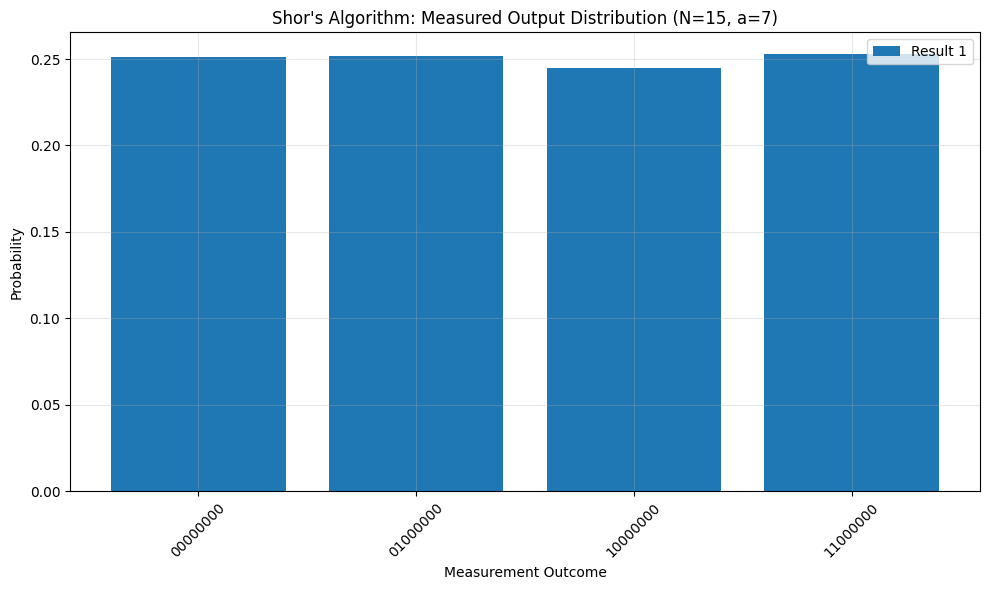

In [8]:
print(f"\nPlotting histogram for Shor's manual circuit")
res_manual.plot(title=f"Shor's Algorithm: Measured Output Distribution (N={N}, a={a})")

### Extracting Factors from Manual Circuit Results

Finally, let's complete the algorithm manually!
Because the measurement process is probabilistic, the most frequent measurement might correspond to a harmonic $s$ that shares a common factor with $r$ (e.g., $s=2, r=4$ reduces to $1/2$, giving a false period of $2$). 

A robust Shor's implementation iterates through the most probable measurements until it finds a valid period that yields non-trivial factors.

In [9]:
import math
from fractions import Fraction

print("=== Extracting Factors from Manual Circuit ===")
counts = res_manual.get_counts()

# Sort non-zero measurements by frequency
sorted_measurements = sorted([k for k in counts.keys() if int(k, 2) != 0], key=lambda k: counts[k], reverse=True)

factors_found = False
for best_y_bin in sorted_measurements[:4]:  # Check the top few peaks
    best_y = int(best_y_bin, 2)
    phase = best_y / Q
    frac = Fraction(phase).limit_denominator(N)
    r_measured = frac.denominator
    
    print(f"\nTesting measurement y = {best_y:>3} | Phase = {phase:>6.4f} | Fraction = {frac.numerator}/{frac.denominator} | Recovered r = {r_measured}")
    
    # 1. Verify if r is the true period
    if pow(a, r_measured, N) != 1:
        print(f"   → [Skip] {a}^{r_measured} mod {N} != 1. This happens when the harmonic 's' and period 'r' share a factor.")
        continue
        
    # 2. Check if period is even
    if r_measured % 2 != 0:
        print("   → [Skip] Period is odd.")
        continue
        
    # 3. Calculate factors
    x = pow(a, r_measured // 2, N)
    f1 = math.gcd(x + 1, N)
    f2 = math.gcd(x - 1, N)
    
    # 4. Verify factors
    if f1 > 1 and f2 > 1 and f1 * f2 == N:
        print(f"   → [Success] Factors found: {f1} × {f2} = {N}! ✅")
        factors_found = True
        break
    elif f1 * f2 != N:
        # Sometimes the gcds are N and 1, or they multiply to something else if x = +/- 1
        if f1 > 1 and f1 < N:
            print(f"   → [Success] Factor found: {f1} × {N//f1} = {N}! ✅")
            factors_found = True
            break
        elif f2 > 1 and f2 < N:
            print(f"   → [Success] Factor found: {f2} × {N//f2} = {N}! ✅")
            factors_found = True
            break
        else:
            print(f"   → [Skip] Trivial factors found ({f1}, {f2}).")

if not factors_found:
    print("\nCould not find factors from the top measurements. Try running the circuit again.")


=== Extracting Factors from Manual Circuit ===

Testing measurement y = 192 | Phase = 0.7500 | Fraction = 3/4 | Recovered r = 4
   → [Success] Factors found: 5 × 3 = 15! ✅


### Results Interpretation

In the ideal (noiseless) case, you should observe:

- **$r$ equally spaced peaks** in the histogram, at positions $y = 0, Q/r, 2Q/r, \ldots, (r-1)Q/r$.
- Each peak has probability $\approx 1/r$.

**What the histogram shows:**
- **X-axis:** Measured $t$-bit outcomes from the precision register.
- **Y-axis:** Probability of each outcome.
- **Ideal case:** $r$ peaks at multiples of $Q/r$ (for $N=15, a=7$: peaks at $y = 0, 64, 128, 192$).

**Post-processing:**
- For each non-zero measurement $y$, compute $y/Q \approx s/r$.
- Apply the **continued fractions** algorithm to find the denominator $r$.
- Use $r$ to compute factors: $\gcd(a^{r/2} \pm 1, N)$.

**Example for $N = 15, a = 7$:**
- $r = 4$, so $a^{r/2} = 7^2 = 49 \equiv 4 \pmod{15}$.
- $\gcd(4 + 1, 15) = \gcd(5, 15) = 5$ ✅
- $\gcd(4 - 1, 15) = \gcd(3, 15) = 3$ ✅
- **Factors:** $15 = 3 \times 5$.

## 6. Exercises

**Beginner:**

1. Use the classical helper functions above to verify the periods of $a^x \bmod 15$ for $a = 2, 4, 7, 11, 13$. Which values of $a$ lead to successful factoring?
2. What happens if you choose $a$ that shares a common factor with $N$? (e.g., $a = 3, N = 15$). Why is this a "lucky" case?

**Intermediate:**

3. Use `ShorsAlgorithm(N=15)` and manually call `find_period(a=7)` to see the quantum period-finding step. How does the returned period compare to the classical calculation?
4. Explain why the algorithm fails when $r$ is odd. (Hint: what does $a^{r/2}$ mean when $r$ is odd?)

**Advanced:**

5. Implement a function that takes a measurement outcome $y$ and the total $Q = 2^t$, and uses `Fraction(y/Q).limit_denominator(N)` to extract the period via continued fractions. Test it on the expected peaks for $N = 15, a = 7$.
6. Research the connection between Shor's algorithm and the **Quantum Phase Estimation (QPE)** algorithm. How can Shor's period-finding circuit be viewed as a special case of QPE applied to the unitary $U|y\rangle = |ay \bmod N\rangle$?

## 7. Key Takeaways

- **Shor's algorithm** factors an integer $N$ in **$O((\log N)^3)$** time, an exponential speedup over the best known classical algorithms.
- The algorithm reduces factoring to **period-finding**: given $f(x) = a^x \bmod N$, find the smallest $r$ such that $a^r \equiv 1 \pmod{N}$.
- The quantum circuit uses **two registers**: a precision register (for the QFT) and a target register (for modular exponentiation).
- The **Quantum Fourier Transform** converts the periodic structure of $a^x \bmod N$ into measurable peaks, from which $r$ is extracted via **continued fractions**.
- Once $r$ is known, factors are computed classically using $\gcd(a^{r/2} \pm 1, N)$.
- Shor's algorithm has profound implications for **cryptography**: it breaks RSA encryption, which relies on the difficulty of factoring large integers.
- This educational implementation uses a **simplified modular exponentiation circuit** suitable for small $N \leq 20$. Production implementations require efficient circuits for modular multiplication.
- The QpiAI SDK provides both a **low-level `Circuit` API** for manual construction and a **high-level `ShorsAlgorithm` class** with methods like `build_circuit()`, `find_period()`, and `factor()`.

---
**Thank you for learning with QpiAI!**

In [10]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.34
